## cleaning & analysis
all procedural communications from Brazil's Judicial Gazette that mentions "recuperação judicial" in TJSP (jun25-jun26)

In [144]:
import pandas as pd
import ast
import re
from bs4 import BeautifulSoup
import html

In [2]:
df = pd.read_csv('df_jun25_jun26.csv')
df

C:\Users\samue\AppData\Local\Temp\ipykernel_11788\2494632136.py:1: DtypeWarning: Columns (0: motivo_cancelamento, 1: data_cancelamento) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df_jun25_jun26.csv')


,id,data_disponibilizacao,siglaTribunal,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,meio,link,...,ativo,hash,status,motivo_cancelamento,data_cancelamento,datadisponibilizacao,meiocompleto,numeroprocessocommascara,destinatarios,destinatarioadvogados
0,285008418,2025-06-02,TJSP,Intimação,Foro Regional I - Santana - 1ª Vara Cível,93198,Processo 1000274-98.2024.8.26.0003 - Execução ...,10002749820248260003,D,https://www.dje.tjsp.jus.br,...,True,on1OxBm7REQs4vhaTpdy1jR3revpEj,P,NaN,NaN,02/06/2025,Diário de Justiça Eletrônico Nacional,1000274-98.2024.8.26.0003,"[{'comunicacao_id': 285008418, 'nome': 'BANCO ...","[{'id': 481702421, 'comunicacao_id': 285008418..."
1,285008732,2025-06-02,TJSP,Intimação,Foro de Campinas - 1ª Vara do Juizado Especial...,70743,Processo 0004020-46.2024.8.26.0114 (processo p...,40204620248260114,D,https://www.dje.tjsp.jus.br,...,True,8adD75Pq6DosBxIATgELJnRnyG1xNL,P,NaN,NaN,02/06/2025,Diário de Justiça Eletrônico Nacional,0004020-46.2024.8.26.0114,"[{'comunicacao_id': 285008732, 'nome': 'EDUARD...","[{'id': 481702973, 'comunicacao_id': 285008732..."
2,285013039,2025-06-02,TJSP,Intimação,Foro Regional IV - Lapa - 4ª Vara Cível,93180,Processo 1116423-80.2024.8.26.0100 - Monitória...,11164238020248260100,D,https://www.dje.tjsp.jus.br,...,True,Ly1D82wNZynsqjdtnTkgOlNY5eBjo9,P,NaN,NaN,02/06/2025,Diário de Justiça Eletrônico Nacional,1116423-80.2024.8.26.0100,"[{'comunicacao_id': 285013039, 'nome': 'DROGA ...","[{'id': 481710156, 'comunicacao_id': 285013039..."
3,285014254,2025-06-02,TJSP,Intimação,Foro de Piracicaba - 3ª Vara Cível,70642,Processo 1000381-59.2024.8.26.0451 - Procedime...,10003815920248260451,D,https://www.dje.tjsp.jus.br,...,True,A7mjrylDZjBse8VFgTWJo9XZwL5MW2,P,NaN,NaN,02/06/2025,Diário de Justiça Eletrônico Nacional,1000381-59.2024.8.26.0451,"[{'comunicacao_id': 285014254, 'nome': 'GABRIE...","[{'id': 481712245, 'comunicacao_id': 285014254..."
4,285015398,2025-06-02,TJSP,Intimação,Foro de Jundiaí - Vara do Juizado Especial Cível,92107,Processo 1009104-08.2024.8.26.0309 - Procedime...,10091040820248260309,D,https://www.dje.tjsp.jus.br,...,True,rEbP1yJdZlOs5Oai1T7EK4w6eXxa8G,P,NaN,NaN,02/06/2025,Diário de Justiça Eletrônico Nacional,1009104-08.2024.8.26.0309,"[{'comunicacao_id': 285015398, 'nome': '123 VI...","[{'id': 481714076, 'comunicacao_id': 285015398..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239373,655376291,2026-06-30,TJSP,Intimação,UPJ da 1ª a 3ª Varas Cíveis - Regional XV - Bu...,100588,<b>Embargos à Execução Nº 4003844-38.2025.8.2...,40038443820258260704,D,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,...,True,Dbmx4M3ZqOsme9wfyTJ1j2dRgozp85,P,NaN,NaN,30/06/2026,Diário de Justiça Eletrônico Nacional,4003844-38.2025.8.26.0704,"[{'nome': 'ALESSANDRO IBIAPINA', 'comunicacao_...","[{'id': 1208974424, 'comunicacao_id': 65537629..."
239374,655376444,2026-06-30,TJSP,Intimação,Central de Mandados - São Vicente,102810,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,10279225320248260100,D,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,...,True,xDnJOQm6NGsW9eBFoTy97BGZkWV9dl,P,NaN,NaN,30/06/2026,Diário de Justiça Eletrônico Nacional,1027922-53.2024.8.26.0100,[{'nome': 'CONCESSIONARIA SPMAR S.A. - EM RECU...,"[{'id': 1208974654, 'comunicacao_id': 65537644..."
239375,655376756,2026-06-30,TJSP,Intimação,UPJ da 6ª a 10ª Varas Cíveis - Foro Central Cível,98506,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,11680306920238260100,D,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,...,True,pOqvB2lR3Ds5nJ5I9TXG5xe6yPD35n,P,NaN,NaN,30/06/2026,Diário de Justiça Eletrônico Nacional,1168030-69.2023.8.26.0100,"[{'nome': 'BANCO ABC BRASIL S.A.', 'comunicaca...","[{'id': 1208975125, 'comunicacao_id': 65537675..."
239376,655377476,2026-06-30,TJSP,Intimação,UPJ da 1ª a 5ª Varas Cíveis - Regional XI - Pi...,100621,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,10038305020258260011,D,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,...,True,

In [3]:
df.columns

Index(['id', 'data_disponibilizacao', 'siglaTribunal', 'tipoComunicacao',
       'nomeOrgao', 'idOrgao', 'texto', 'numero_processo', 'meio', 'link',
       'tipoDocumento', 'nomeClasse', 'codigoClasse', 'numeroComunicacao',
       'ativo', 'hash', 'status', 'motivo_cancelamento', 'data_cancelamento',
       'datadisponibilizacao', 'meiocompleto', 'numeroprocessocommascara',
       'destinatarios', 'destinatarioadvogados'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239378 entries, 0 to 239377
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        239378 non-null  int64 
 1   data_disponibilizacao     239378 non-null  str   
 2   siglaTribunal             239378 non-null  str   
 3   tipoComunicacao           239378 non-null  str   
 4   nomeOrgao                 239378 non-null  str   
 5   idOrgao                   239378 non-null  int64 
 6   texto                     239378 non-null  str   
 7   numero_processo           239378 non-null  object
 8   meio                      239378 non-null  str   
 9   link                      193360 non-null  str   
 10  tipoDocumento             239378 non-null  str   
 11  nomeClasse                237086 non-null  str   
 12  codigoClasse              239378 non-null  int64 
 13  numeroComunicacao         239378 non-null  int64 
 14  ativo          

In [5]:
df.isnull().sum()
#checking for null values

id                               0
data_disponibilizacao            0
siglaTribunal                    0
tipoComunicacao                  0
nomeOrgao                        0
idOrgao                          0
texto                            0
numero_processo                  0
meio                             0
link                         46018
tipoDocumento                    0
nomeClasse                    2292
codigoClasse                     0
numeroComunicacao                0
ativo                            0
hash                             0
status                           0
motivo_cancelamento         237086
data_cancelamento           237086
datadisponibilizacao             0
meiocompleto                     0
numeroprocessocommascara         0
destinatarios                 2292
destinatarioadvogados         2292
dtype: int64

In [6]:
#droping columns that i won't need
df = df.drop(columns = ['siglaTribunal', 'meio', 'motivo_cancelamento', 'data_cancelamento', 'meiocompleto', 'numeroprocessocommascara', 'status', 'datadisponibilizacao', 'numeroComunicacao', 'hash'])
df.shape

(239378, 14)

In [7]:
df.head(5)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados
0,285008418,2025-06-02,Intimação,Foro Regional I - Santana - 1ª Vara Cível,93198,Processo 1000274-98.2024.8.26.0003 - Execução ...,10002749820248260003,https://www.dje.tjsp.jus.br,Intimação,EXECUçãO DE TíTULO EXTRAJUDICIAL,12154,True,"[{'comunicacao_id': 285008418, 'nome': 'BANCO ...","[{'id': 481702421, 'comunicacao_id': 285008418..."
1,285008732,2025-06-02,Intimação,Foro de Campinas - 1ª Vara do Juizado Especial...,70743,Processo 0004020-46.2024.8.26.0114 (processo p...,40204620248260114,https://www.dje.tjsp.jus.br,Intimação,CUMPRIMENTO DE SENTENçA,156,True,"[{'comunicacao_id': 285008732, 'nome': 'EDUARD...","[{'id': 481702973, 'comunicacao_id': 285008732..."
2,285013039,2025-06-02,Intimação,Foro Regional IV - Lapa - 4ª Vara Cível,93180,Processo 1116423-80.2024.8.26.0100 - Monitória...,11164238020248260100,https://www.dje.tjsp.jus.br,Intimação,MONITóRIA,40,True,"[{'comunicacao_id': 285013039, 'nome': 'DROGA ...","[{'id': 481710156, 'comunicacao_id': 285013039..."
3,285014254,2025-06-02,Intimação,Foro de Piracicaba - 3ª Vara Cível,70642,Processo 1000381-59.2024.8.26.0451 - Procedime...,10003815920248260451,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO COMUM CíVEL,7,True,"[{'comunicacao_id': 285014254, 'nome': 'GABRIE...","[{'id': 481712245, 'comunicacao_id': 285014254..."
4,285015398,2025-06-02,Intimação,Foro de Jundiaí - Vara do Juizado Especial Cível,92107,Processo 1009104-08.2024.8.26.0309 - Procedime...,10091040820248260309,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 285015398, 'nome': '123 VI...","[{'id': 481714076, 'comunicacao_id': 285015398..."


## normalize the name of the company
(saved the json file as a csv in the same loop when i got the data from the API)

In [8]:
df['destinatarios']
#how the data is in the column

0         [{'comunicacao_id': 285008418, 'nome': 'BANCO ...
1         [{'comunicacao_id': 285008732, 'nome': 'EDUARD...
2         [{'comunicacao_id': 285013039, 'nome': 'DROGA ...
3         [{'comunicacao_id': 285014254, 'nome': 'GABRIE...
4         [{'comunicacao_id': 285015398, 'nome': '123 VI...
                                ...                        
239373    [{'nome': 'ALESSANDRO IBIAPINA', 'comunicacao_...
239374    [{'nome': 'CONCESSIONARIA SPMAR S.A. - EM RECU...
239375    [{'nome': 'BANCO ABC BRASIL S.A.', 'comunicaca...
239376    [{'nome': 'CENTRAL DO ADUBO COM E REPRESENTACA...
239377    [{'nome': 'BANCO VOTORANTIM S.A.', 'comunicaca...
Name: destinatarios, Length: 239378, dtype: str

In [9]:
df['destinatarios'].iloc[0]

"[{'comunicacao_id': 285008418, 'nome': 'BANCO DO BRASIL S/A', 'polo': 'A'}, {'comunicacao_id': 285008418, 'nome': 'ODAIR CAZEMIRO', 'polo': 'P'}]"

In [10]:
df['destinatarios'].iloc[239377]

"[{'nome': 'BANCO VOTORANTIM S.A.', 'comunicacao_id': 655379949, 'polo': 'A'}]"

In [11]:
df['texto'].iloc[239377]
#text of the court decision

'<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style></style>\n\t</head>\n\t<body>\n\t\t<article>\n\n\n\n\n\n<header>\n\t\t\t\t<div></div> \n\t\t\t\t \n\t\t\t\t \n\t\t\t\t \n\t\t\t\t \t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t</header>\n<section><b>EXECU&Ccedil;&Atilde;O DE T&Iacute;TULO EXTRAJUDICIAL  N&ordm; 4112348-73.2026.8.26.0100/SP</b></section>\n<section><b><table><tr><td>EXEQUENTE</td><td>: BANCO VOTORANTIM S.A.</td></tr><tr><td>ADVOGADO(A)</td><td>: CINTHIA ACHAO DE LAMARE (OAB SP438700)</td></tr><tr><td>ADVOGADO(A)</td><td>: LIZAH ELLEN GELD RIBEIRO (OAB SP483702)</td></tr></table></b></section>\n<section>\n\t\t\t\t<p align="center">DESPACHO/DECIS&Atilde;O</p>\n\t\t\t</section>\n<section>\n<p>Vistos.</p>\n<p>Trata-se de EXECU&Ccedil;&Atilde;O DE T&Iacute;TULO EXTRAJUDICIAL&nbsp;proposta por BANCO VOTORANTIM S.A.&nbsp;em face de FLEX GESTAO DE RELACIONAMENTOS S.A. EM RECUPERACAO JUDICIAL&nbsp;com base em titulo extrajudicial.</p>\n<p><span><strong>Cite-se</strong> a parte executada par

In [12]:
#converting the string to a list so I could extract the company's name
df['destinatarios'] = df['destinatarios'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [13]:
#getting the company that filed the case (polo A)

df['company_A'] = df['destinatarios'].apply(
    lambda ds: (
        None
        if not isinstance(ds, list)
        else (
            empresas := [d['nome'] for d in ds if d['polo'] == 'A']
        ) or None
    )
)

In [14]:
df.isnull().sum()

id                           0
data_disponibilizacao        0
tipoComunicacao              0
nomeOrgao                    0
idOrgao                      0
texto                        0
numero_processo              0
link                     46018
tipoDocumento                0
nomeClasse                2292
codigoClasse                 0
ativo                        0
destinatarios             2292
destinatarioadvogados     2292
company_A                22449
dtype: int64

In [15]:
df.head(20)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A
0,285008418,2025-06-02,Intimação,Foro Regional I - Santana - 1ª Vara Cível,93198,Processo 1000274-98.2024.8.26.0003 - Execução ...,10002749820248260003,https://www.dje.tjsp.jus.br,Intimação,EXECUçãO DE TíTULO EXTRAJUDICIAL,12154,True,"[{'comunicacao_id': 285008418, 'nome': 'BANCO ...","[{'id': 481702421, 'comunicacao_id': 285008418...",[BANCO DO BRASIL S/A]
1,285008732,2025-06-02,Intimação,Foro de Campinas - 1ª Vara do Juizado Especial...,70743,Processo 0004020-46.2024.8.26.0114 (processo p...,40204620248260114,https://www.dje.tjsp.jus.br,Intimação,CUMPRIMENTO DE SENTENçA,156,True,"[{'comunicacao_id': 285008732, 'nome': 'EDUARD...","[{'id': 481702973, 'comunicacao_id': 285008732...",[EDUARDO QUAGLIATO]
2,285013039,2025-06-02,Intimação,Foro Regional IV - Lapa - 4ª Vara Cível,93180,Processo 1116423-80.2024.8.26.0100 - Monitória...,11164238020248260100,https://www.dje.tjsp.jus.br,Intimação,MONITóRIA,40,True,"[{'comunicacao_id': 285013039, 'nome': 'DROGA ...","[{'id': 481710156, 'comunicacao_id': 285013039...",[F&F DISTRIBUIDORA DE PRODUTOS FARMACêUTICOS L...
3,285014254,2025-06-02,Intimação,Foro de Piracicaba - 3ª Vara Cível,70642,Processo 1000381-59.2024.8.26.0451 - Procedime...,10003815920248260451,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO COMUM CíVEL,7,True,"[{'comunicacao_id': 285014254, 'nome': 'GABRIE...","[{'id': 481712245, 'comunicacao_id': 285014254...",[GABRIEL PEDROSO SOTTOPIETRO]
4,285015398,2025-06-02,Intimação,Foro de Jundiaí - Vara do Juizado Especial Cível,92107,Processo 1009104-08.2024.8.26.0309 - Procedime...,10091040820248260309,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 285015398, 'nome': '123 VI...","[{'id': 481714076, 'comunicacao_id': 285015398...","[JOSIANE APARECIDA NOGUEIRA DE ALMEIDA, JULIAN..."
5,285015695,2025-06-02,Intimação,Foro Regional II - Santo Amaro - 6ª Vara Cível,93591,Processo 1093680-79.2024.8.26.0002 - Procedime...,10936807920248260002,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO COMUM CíVEL,7,True,"[{'comunicacao_id': 285015695, 'nome': 'ASSOCI...","[{'id': 481714633, 'comunicacao_id': 285015695...",[JACI LEOPOLDO DE MELO]
6,285016006,2025-06-02,Intimação,Foro de Campinas - 1ª Vara do Juizado Especial...,70743,Processo 0014446-20.2024.8.26.0114 - Procedime...,144462020248260114,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 285016006, 'nome': 'INIPLA...","[{'id': 481715144, 'comunicacao_id': 285016006...",None
7,285016299,2025-06-02,Intimação,Foro de Sorocaba - 1ª Vara do Juizado Especial...,93576,Processo 1027987-36.2020.8.26.0602 - Procedime...,10279873620208260602,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 285016299, 'nome': 'ASSIST...","[{'id': 481715603, 'comunicacao_id': 285016299...",[ASSISTEC SOLDA COMéRCIO E SERVIçOS LTDA]
8,285016406,2025-06-02,Intimação,Foro de Sorocaba - 1ª Vara do Juizado Especial...,93576,Processo 1020225-27.2024.8.26.0602 - Procedime...,10202252720248260602,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 285016406, 'nome': 'BANCO ...","[{'id': 481715807, 'comunicacao_id': 285016406...",[LIDIANE CABRAL TERRA FONSECA]
9,285016646,2025-06-02,Intimação,Foro Regional I - Santana - 7ª Vara Cível,93344,Processo 0014784-13.2022.8.26.0001 (processo p...,147841320228260001,https://www.dje.tjsp.jus.br,Intimação,CUMPRIMENTO DE SENTENçA,156,True,"[{'comunicacao_id': 285016646, 'nome': 'GLAUCI...","[{'id': 481716241, 'comunicacao_id': 285016646...","[GLAUCIA ALVARES GALOTTI DE ALMEIDA, NEILDES A..."


In [16]:
# destinatarios exist, but company_A in null
# this happens because sometimes there's no company in 'polo' A (moving the lawsuit), only polo P (defendant of the lawsuit)
df[df['company_A'].isna() & df['destinatarios'].notna()][['destinatarios', 'company_A']].head(10)

,destinatarios,company_A
6,"[{'comunicacao_id': 285016006, 'nome': 'INIPLA...",None
13,"[{'comunicacao_id': 285019459, 'nome': 'LOJAS ...",None
15,"[{'comunicacao_id': 285021742, 'nome': 'VIAGEN...",None
29,"[{'comunicacao_id': 285037302, 'nome': '123 VI...",None
50,"[{'comunicacao_id': 285055698, 'nome': 'R. L. ...",None
160,"[{'comunicacao_id': 285109404, 'nome': 'ENTREM...",None
172,"[{'comunicacao_id': 285113331, 'nome': 'IVA QU...",None
184,"[{'comunicacao_id': 285124283, 'nome': 'PENIDO...",None
185,"[{'comunicacao_id': 285124541, 'nome': 'CARDAL...",None
186,"[{'comunicacao_id': 285124548, 'nome': 'CARDAL...",None


In [17]:
#checking if there's no polo A
df['destinatarios'].loc[185]

[{'comunicacao_id': 285124541,
  'nome': 'CARDAL ELETRO METALURGICA LTDA',
  'polo': 'P'}]

In [18]:
#checking if there's no polo A
df['destinatarios'].loc[186]

[{'comunicacao_id': 285124548,
  'nome': 'CARDAL ELETRO METALURGICA LTDA',
  'polo': 'P'}]

In [19]:
#checking if there's no polo A
df['destinatarios'].loc[184]

[{'comunicacao_id': 285124283,
  'nome': 'PENIDO CONSTRUTORA E PAVIMENTADORA LTDA EM RECUPERACAO JUDICIAL',
  'polo': 'P'}]

In [ ]:
#checking the court decision (trying to understand why there's no polo P)
#tax case
df['texto'].loc[184]

'Processo 1504338-89.2022.8.26.0577 - Execução Fiscal - IPTU/ Imposto Predial e Territorial Urbano - Penido Construtora e Pavimentadora Ltda Em Recuperacao Judicial - Vistos. Reconsidero o despacho de fls. 99. A executada encontra-se citada em razão de seu comparecimento espontâneo (art. 239 § 1º CPC). Defiro à executada os benefícios da justiça gratuita. Ante a não concordância do bem indicado à penhora, declaro ineficaz a nomeação realizada às fls. 11/18. Int. - ADV: MARCO AURELIO DE MATTOS CARVALHO (OAB 92415/SP), DEBORA CRISTINA P DE O MATTOS CARVALHO (OAB 132178/SP)'

## understanding the data

In [21]:
df['tipoComunicacao'].unique()

<ArrowStringArray>
['Intimação', 'Citação', 'Ata de sessão']
Length: 3, dtype: str

In [22]:
df['tipoDocumento'].unique()

<ArrowStringArray>
[                          'Intimação',                            'Entrados',
                        'Distribuídos',                'Intimação de acórdão',
                            'Despacho',                               'VISTA',
                    'DESPACHO/DECISÃO',                            'Sentença',
                     'Ato ordinatório',                          'DILIGÊNCIA',
                                  '80', 'Despacho de Intimação Conciliatória',
      'Resultado Sessão Conciliatória',                             'Acórdão',
         'Ata de sessão de julgamento',                              'Outros',
                            'Julgados',                   'EDITAL DE CITAÇÃO']
Length: 18, dtype: str

In [23]:
df[df['tipoDocumento'] == 'Distribuídos']

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A
276,285336349,2025-06-02,Intimação,Distribuição Originários Direito Privado 3 - P...,92588,PROCESSOS DISTRIBUÍDOS EM 29/05/2025\r\n\r\n21...,21623745520258260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285336349, 'nome': 'LIVRAR...","[{'id': 482368074, 'comunicacao_id': 285336349...",[MARIANA ARTEIRO GARGIULO]
314,285414586,2025-06-02,Intimação,Distribuição de Direito Privado 3 - Rua: dos S...,92319,PROCESSOS DISTRIBUÍDOS EM 29/05/2025\r\n\r\n10...,10061168320248260286,https://www.dje.tjsp.jus.br,Distribuídos,APELAçãO CíVEL,198,True,"[{'comunicacao_id': 285414586, 'nome': 'ALESSA...","[{'id': 482546814, 'comunicacao_id': 285414586...",[SAVIOLI COMéRCIO DE FRUTAS LTDA.]
315,285414721,2025-06-02,Intimação,Distribuição de Direito Privado 3 - Rua: dos S...,92319,PROCESSOS DISTRIBUÍDOS EM 29/05/2025\r\n\r\n10...,10284802520248260100,https://www.dje.tjsp.jus.br,Distribuídos,APELAçãO CíVEL,198,True,"[{'comunicacao_id': 285414721, 'nome': 'CONCES...","[{'id': 482547134, 'comunicacao_id': 285414721...",[LUCIENE MARIA DE JESUS MORAIS]
316,285423802,2025-06-02,Intimação,"Distribuição Originários Direito Público, Câm....",92362,PROCESSOS DISTRIBUÍDOS EM 29/05/2025\r\n\r\n21...,21627833120258260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285423802, 'nome': 'DIPLAD...","[{'id': 482565139, 'comunicacao_id': 285423802...",[DIPLADENIA EMPREENDIMENTOS IMOBILIáRIOS LTDA]
341,285465570,2025-06-02,Intimação,"Distribuição Originários Direito Público, Câm....",92362,PROCESSOS DISTRIBUÍDOS EM 29/05/2025\r\n\r\n30...,30071865220258260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285465570, 'nome': 'ESTADO...","[{'id': 482660337, 'comunicacao_id': 285465570...",[ESTADO DE SãO PAULO]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238775,654705267,2026-06-30,Intimação,Distribuição Originários Direito Privado 1 e C...,92618,PROCESSOS DISTRIBUÍDOS EM 26/06/2026\r\n\r\n21...,21619143420268260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,"[{'nome': 'AMERICANA FRANQUIA S A', 'polo': 'P...","[{'id': 1207513183, 'comunicacao_id': 65470526...",[SOUTHROCK CAPITAL LTDA]
238776,654705298,2026-06-30,Intimação,Distribuição Originários Direito Privado 1 e C...,92618,PROCESSOS DISTRIBUÍDOS EM 26/06/2026\r\n\r\n21...,21619637520268260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,[{'nome': 'FY83 PARTICIPAçõES E INVESTIMENTOS ...,"[{'id': 1207513296, 'comunicacao_id': 65470529...","[FY83 PARTICIPAçõES E INVESTIMENTOS LTDA, GRES..."
238821,654736318,2026-06-30,Intimação,Distribuição Originários Direito Privado 1 e C...,92618,PROCESSOS DISTRIBUÍDOS EM 24/06/2026\r\n\r\n21...,21595551420268260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,[{'nome': 'DIA 33 ENERGIES GENERAL TRADING LLC...,"[{'id': 1207575134, 'comunicacao_id': 65473631...","[DIA 33 ENERGIES GENERAL TRADING LLC, DIA33 EN..."
238822,654736376,2026-06-30,Intimação,Distribuição Originários Direito Privado 1 e C...,92618,PROCESSOS DISTRIBUÍDOS EM 24/06/2026\r\n\r\n30...,30087737520268260000,https://www.dje.tjsp.jus.br,Distribuídos,AGRAVO DE INSTRUMENTO,202,True,[{'nome': 'EDEP ENGENHARIA E CONSULTORIA S.A.'...,"[{'id': 1207575306, 'comunicacao_id': 65473637...",[ESTADO DE SãO PAULO]


In [24]:
df.loc[276, 'texto']

'PROCESSOS DISTRIBUÍDOS EM 29/05/2025\r\n\r\n2162374-55.2025.8.26.0000; Processo Digital. Petições para juntada devem ser apresentadas exclusivamente por meio eletrônico, nos termos do artigo 7º da Res. 551/2011; Agravo de Instrumento; 26ª Câmara de Direito Privado; MARIA DE LOURDES LOPEZ GIL; Foro Central Cível; 39ª Vara Cível; Cumprimento de sentença; 0017063-58.2025.8.26.0100; Compra e Venda; Agravante: Mariana Arteiro Gargiulo; Advogada: Mariana Arteiro Gargiulo (OAB: 214362/SP) (Causa própria); Agravado: Livraria Cultura S A (Em Recuperação Judicial); Advogado: Leon Alexander Prist (OAB: 303213/SP); Advogada: Marina de Sousa Alves (OAB: 423229/SP); Advogada: Ana Paula de Azevedo Defensor (OAB: 289493/SP); Interessado: Catapulta Editores Ltda.; Advogada: Mariana Arteiro Gargiulo (OAB: 214362/SP); Ficam as partes intimadas para se manifestarem acerca de eventual oposição\xa0motivada\xa0ao julgamento virtual, nos termos do art. 1º da Resolução 549/2011, do Órgão Especial deste Tribun

In [25]:
df[df['tipoDocumento'] == 'Entrados']

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A
250,285274138,2025-06-02,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 28/05/2025\r\n\r\n2162927-...,21629270520258260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285274138, 'nome': 'O JUIZ...","[{'id': 482232887, 'comunicacao_id': 285274138...",[RODRIMAR S/A TERMINAIS PORTUáRIOS ARMAZéNS GE...
251,285274225,2025-06-02,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 28/05/2025\r\n\r\n2163009-...,21630093620258260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285274225, 'nome': 'FERRAR...","[{'id': 482233156, 'comunicacao_id': 285274225...",[FERRARI & FOLLE DROGARIA LTDA]
253,285274271,2025-06-02,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 28/05/2025\r\n\r\n2163062-...,21630621720258260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285274271, 'nome': 'BANCO ...","[{'id': 482233323, 'comunicacao_id': 285274271...",[BANCO GUANABARA S/A]
254,285274314,2025-06-02,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 28/05/2025\r\n\r\n2163137-...,21631375620258260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285274314, 'nome': 'O JUIZ...","[{'id': 482233511, 'comunicacao_id': 285274314...",[TAEKO KUNITOMO]
255,285274361,2025-06-02,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 29/05/2025\r\n\r\n2163226-...,21632267920258260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'comunicacao_id': 285274361, 'nome': 'BANCO ...","[{'id': 482233580, 'comunicacao_id': 285274361...",[BANCO BRADESCO S/A]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238746,654680294,2026-06-30,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 25/06/2026\r\n\r\n2162034-...,21620347720268260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,[{'nome': 'DELTA USINAGEM E FUNDIDOS LTDA - EM...,"[{'id': 1207453034, 'comunicacao_id': 65468029...",[VALDIR ALVES DOS SANTOS]
238747,654680311,2026-06-30,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 25/06/2026\r\n\r\n2162085-...,21620858820268260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,[{'nome': 'ANHANGUERA IND.COM.PISOS REVES.LTDA...,"[{'id': 1207453084, 'comunicacao_id': 65468031...",[MARCELO ANTONIO DA SILVA]
238748,654680369,2026-06-30,Intimação,Entrada Originários Direito Privado 1 e Câm. E...,92175,PROCESSO ENTRADO EM 25/06/2026\r\n\r\n2162214-...,21622149320268260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'nome': 'CRUZAçO FUNDIçãO E MECâNICA LTDA.',...","[{'id': 1207453292, 'comunicacao_id': 65468036...",[WILLIAM MATHEUS RODRIGUES DE JESUS]
238824,654736754,2026-06-30,Intimação,Entrada Originários - Direito Privado 2 - Pate...,93990,PROCESSO ENTRADO EM 26/06/2026\r\n\r\n2162451-...,21624513020268260000,https://www.dje.tjsp.jus.br,Entrados,AGRAVO DE INSTRUMENTO,202,True,"[{'nome': 'JOSé PUPIN', 'polo': 'P', 'comunica...","[{'id': 1207576343, 'comunicacao_id': 65473675...",[KRIPTA FUNDO DE INVESTIMENTO EM DIREITOSCREDI...


In [26]:
df.loc[250, 'texto']

'PROCESSO ENTRADO EM 28/05/2025\r\n\r\n2162927-05.2025.8.26.0000; Processo Digital. Petições para juntada devem ser apresentadas exclusivamente por meio eletrônico, nos termos do artigo 7º da Res. 551/2011; Agravo de Instrumento; Comarca: Santos; Vara: 12ª Vara Cível; Ação: Recuperação Judicial; Nº origem: 1011127-17.2019.8.26.0562; Assunto: Recuperação judicial e Falência; Agravante: Rodrimar S/A Terminais Portuários Armazéns Gerais Companhia Docas do Estado de São Paulo - CODESP e outros; Advogado: Fernando Gomes dos Reis Lobo (OAB: 183676/SP); Agravado: O Juizo; Interessado: Laspro Consultores Ltda - Administradora Judicial (Administrador Judicial); Advogado: Oreste Nestor de Souza Laspro (OAB: 98628/SP); Interessado: Grcmac Locações e Equipamentos Ltda; Advogada: Andressa Felix Lisboa (OAB: 448482/SP); Advogado: Marcelo Lamy (OAB: 122446/SP); Interessado: Port Master Operador Portuário Ltda; Advogado: Fernando de Albuquerque Rocco (OAB: 325850/SP); Interessada: Sonia Maria Rodrigue

In [27]:
df[df['tipoDocumento'] == 'Ato ordinatório']

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A
3946,289926057,2025-06-05,Intimação,Ofício Único da 1ª e 2ª Vara do JEC de Osasco,94583,"<!DOCTYPE html PUBLIC ""-//W3C//DTD HTML 4.01//...",40005414020258260405,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 289926057, 'nome': 'YEESCO...","[{'id': 491591618, 'comunicacao_id': 289926057...",None
3947,289926246,2025-06-05,Intimação,Ofício Único da 1ª e 2ª Vara do JEC de Osasco,94583,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40005414020258260405,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 289926246, 'nome': 'YEESCO...","[{'id': 491591948, 'comunicacao_id': 289926246...",None
17772,307365192,2025-06-25,Intimação,1ª Vara do Juizado Especial Cível - Regional V...,94881,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40007703020258260007,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 307365192, 'nome': '123 VI...","[{'id': 525293995, 'comunicacao_id': 307365192...",None
22868,314116863,2025-07-02,Intimação,Vara do Juizado Especial Cível da Comarca de C...,94439,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40000210720258260106,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 314116863, 'nome': 'AMERIC...","[{'id': 539331289, 'comunicacao_id': 314116863...",None
24158,316009933,2025-07-04,Intimação,1ª Vara do Juizado Especial Cível - JEC Centra...,94485,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40026278420258260016,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 316009933, 'nome': 'CONCRE...","[{'id': 543537972, 'comunicacao_id': 316009933...",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239340,655338567,2026-06-30,Intimação,UPJ da 1ª a 6ª Varas Cíveis da Comarca de Araç...,102881,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40026322420268260032,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,PROCEDIMENTO COMUM CíVEL,7,True,"[{'nome': 'OI S.A. - EM RECUPERACAO JUDICIAL',...","[{'id': 1208901222, 'comunicacao_id': 65533856...",None
239353,655347600,2026-06-30,Intimação,1ªVara Reg. Comp. Empresarial e Conflitos à Ar...,103588,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40026260720268260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,HABILITAçãO DE CRéDITO,111,True,"[{'nome': 'SARAH CRISTINA NOGUEIRA DA SILVA', ...","[{'id': 1208919835, 'comunicacao_id': 65534760...",[SARAH CRISTINA NOGUEIRA DA SILVA]
239357,655354171,2026-06-30,Intimação,1ªVara Reg. Comp. Empresarial e Conflitos à Ar...,103588,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40000205420258260354,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,IMPUGNAçãO DE CRéDITO,114,True,[{'nome': 'CONDOMINIO DO EDIFICIO III MILENIO'...,"[{'id': 1208933592, 'comunicacao_id': 65535417...",[CONDOMINIO DO EDIFICIO III MILENIO]
239358,655355354,2026-06-30,Intimação,UPJ da 1ª a 4ª Varas Cíveis da Comarca de São ...,102647,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,142152520258260577,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,CUMPRIMENTO DE SENTENçA,156,True,[{'nome': 'INSTITUTO METODISTA DE ENSINO SUPER...,"[{'id': 1208935251, 'comunicacao_id': 65535535...",[INSTITUTO METODISTA DE ENSINO SUPERIOR - EM R...


In [103]:
df.loc[3946, 'texto']

'<!DOCTYPE html PUBLIC "-//W3C//DTD HTML 4.01//EN" "http://www.w3.org/TR/html4/strict.dtd"><html lang="pt-br"><head><meta http-equiv="Pragma" content="no-cache" /><meta http-equiv="Content-Type" content="text/html; charset=iso-8859-1"/></head><style>body{ padding: 10px; font-family: Times New Roman; font-size:13pt }; #divHeader{ line-height:25px; margin-bottom:30px }; #divBody{ max-width:90%; text-align:justify }</style><body><div id="divHeader"><b>PROCEDIMENTO DO JUIZADO ESPECIAL CÍVEL Nº 4000541-40.2025.8.26.0405/SP<table border="0"><tr><td>RELATOR</td><td>: PAULO DE ABREU LORENZINO</td></tr><tr><td>RÉU</td><td>: YEESCO INDUSTRIA E COMERCIO DE CONFECOES LTDA EM RECUPERACAO JUDICIAL</td></tr><tr><td>ADVOGADO(A)</td><td>: RODRIGO SAGRADIN (OAB SC048067)</td></tr></table></b></div><div id="divBody"><center><p>ATO ORDINATÓRIO</p></center><br/><p>Intimação realizada no sistema eproc.</p><p>O ato refere-se ao seguinte evento:</p><p>Evento 10 - 04/06/2025 - Audiência de conciliação - design

In [28]:
df.loc[239374, 'texto']

'<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style></style>\n\t</head>\n\t<body>\n\t\t<article>\n\t\t\t\n\n\n\n\n\n\n\n\n\n<header>\n\t\t\t\t<div></div>\n\t\t\t\t\n\t\t\t\t\n\t\t\t\t\n\t\t\t</header>\n<section><b>Procedimento Comum C&iacute;vel  N&ordm; 1027922-53.2024.8.26.0100/SP</b></section>\n<section>\n\t\t\t\t<p>Assunto: Inadimplemento</p>\n\t\t\t</section>\n<section><b><table><tr><td>AUTOR</td><td>: CONCESSIONARIA SPMAR S.A. - EM RECUPERACAO JUDICIAL</td></tr><tr><td>ADVOGADO(A)</td><td>: ANDREZA GON&Ccedil;ALVES PALUMBO (OAB SP212890)</td></tr></table></b></section>\n<section>\n\t\t\t\t<p align="center">\n\t\t\t\t\tATO ORDINAT&Oacute;RIO\n\t\t\t\t</p>\n\t\t\t</section>\n<section>\n<p><span>O autor se manifestar&aacute; em cinco dias sobre a tentativa infrut&iacute;fera de cita&ccedil;&atilde;o/intima&ccedil;&atilde;o (carta, mandado, carta precat&oacute;ria e outros), no prazo de cinco dias. No sil&ecirc;ncio, tornem conclusos<span>.</span></span></p></section>\n<section>\n\t\t\t\

In [29]:
df['tipoDocumento'].value_counts().reset_index()

,tipoDocumento,count
0,Intimação,165271
1,Despacho,17259
2,DESPACHO/DECISÃO,15318
3,Intimação de acórdão,9723
4,Ato ordinatório,9443
5,Entrados,7818
6,Distribuídos,7503
7,Sentença,3711
8,VISTA,1753
9,Outros,483


In [30]:
df['codigoClasse'].unique()

array([12154,   156,    40,     7,   436,   172, 12119,  1265,   159,
        1709,   111,   108,   129,   157,   114, 14991, 12251,    74,
        1116, 14695,   120,    81,   137,    90,   202,   198,    92,
         221,    38,   460,   138,  1689, 12134,    65, 12135,   151,
       15217,   228,    93,   261, 11397,   152,   178,    49,    37,
       12228,    94,   100,   128,   236,   135,  1266,    45, 12226,
        1118,  1112,   193, 12078,  1707,    39, 12541,  1208,    32,
          83,  1728, 10980,  1682,    84,    22, 12375,   199, 12357,
          69, 12372, 12246,  1702, 12075, 10943, 12133,  1294,  1295,
          52,   283,    97,   241,   166, 10972,   113,   309,   207,
         140,   191,   206,   330,   417,    64, 12763,  1117,    28,
        1199,    31, 12086,    47, 10973, 12079,   167, 12231,    44,
          46,    34,    86,   326, 12081,   279, 10981, 12374,  1683,
         332, 12371,  1271, 14671,   215,    30,   181,    99, 14677,
         112,  1733,

In [31]:
df['id'].duplicated().sum()
#checking if there are duplicated values

np.int64(0)

In [32]:
(df['codigoClasse'] == 129).sum()
#number of reorganization procedural communications

np.int64(20096)

## getting the month and year

In [33]:
#getting the year and the month and putting in another column
#first, converting to datetime object
df['data_disponibilizacao'] = pd.to_datetime(df['data_disponibilizacao'])

In [34]:
df['data_disponibilizacao']

0        2025-06-02
1        2025-06-02
2        2025-06-02
3        2025-06-02
4        2025-06-02
            ...    
239373   2026-06-30
239374   2026-06-30
239375   2026-06-30
239376   2026-06-30
239377   2026-06-30
Name: data_disponibilizacao, Length: 239378, dtype: datetime64[us]

In [35]:
df['data_disponibilizacao'].dt.day_name().value_counts()
#no judicial gazette on the weekends

data_disponibilizacao
Monday       53659
Wednesday    49542
Thursday     47365
Tuesday      44839
Friday       43973
Name: count, dtype: int64

In [36]:
#creating a year column
df["year"] = df["data_disponibilizacao"].dt.year

In [37]:
#creating a month column
df["month"] = df["data_disponibilizacao"].dt.month

In [38]:
#month&year
df["month_year"] = df["data_disponibilizacao"].dt.strftime("%B %Y")

In [39]:
df.head(5)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
0,285008418,2025-06-02,Intimação,Foro Regional I - Santana - 1ª Vara Cível,93198,Processo 1000274-98.2024.8.26.0003 - Execução ...,10002749820248260003,https://www.dje.tjsp.jus.br,Intimação,EXECUçãO DE TíTULO EXTRAJUDICIAL,12154,True,"[{'comunicacao_id': 285008418, 'nome': 'BANCO ...","[{'id': 481702421, 'comunicacao_id': 285008418...",[BANCO DO BRASIL S/A],2025,6,June 2025
1,285008732,2025-06-02,Intimação,Foro de Campinas - 1ª Vara do Juizado Especial...,70743,Processo 0004020-46.2024.8.26.0114 (processo p...,40204620248260114,https://www.dje.tjsp.jus.br,Intimação,CUMPRIMENTO DE SENTENçA,156,True,"[{'comunicacao_id': 285008732, 'nome': 'EDUARD...","[{'id': 481702973, 'comunicacao_id': 285008732...",[EDUARDO QUAGLIATO],2025,6,June 2025
2,285013039,2025-06-02,Intimação,Foro Regional IV - Lapa - 4ª Vara Cível,93180,Processo 1116423-80.2024.8.26.0100 - Monitória...,11164238020248260100,https://www.dje.tjsp.jus.br,Intimação,MONITóRIA,40,True,"[{'comunicacao_id': 285013039, 'nome': 'DROGA ...","[{'id': 481710156, 'comunicacao_id': 285013039...",[F&F DISTRIBUIDORA DE PRODUTOS FARMACêUTICOS L...,2025,6,June 2025
3,285014254,2025-06-02,Intimação,Foro de Piracicaba - 3ª Vara Cível,70642,Processo 1000381-59.2024.8.26.0451 - Procedime...,10003815920248260451,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO COMUM CíVEL,7,True,"[{'comunicacao_id': 285014254, 'nome': 'GABRIE...","[{'id': 481712245, 'comunicacao_id': 285014254...",[GABRIEL PEDROSO SOTTOPIETRO],2025,6,June 2025
4,285015398,2025-06-02,Intimação,Foro de Jundiaí - Vara do Juizado Especial Cível,92107,Processo 1009104-08.2024.8.26.0309 - Procedime...,10091040820248260309,https://www.dje.tjsp.jus.br,Intimação,PROCEDIMENTO DO JUIZADO ESPECIAL CíVEL,436,True,"[{'comunicacao_id': 285015398, 'nome': '123 VI...","[{'id': 481714076, 'comunicacao_id': 285015398...","[JOSIANE APARECIDA NOGUEIRA DE ALMEIDA, JULIAN...",2025,6,June 2025


## separating by class (type of process)

In [34]:
####### Códigos CNJ (type of case)
#API documentation: Projects/CNJ API/tabela-de-classes-justia-estadual.pdf

#Recuperação Extrajudicial 128 = extrajudicial reorganization
#Recuperação Judicial 129 = judicial reorganization
#Relatório Falimentar 135 = reports made by the court-appointed administrator
#Falência de Empresários, Sociedades Empresáriais, Microempresas e Empresas de Pequeno Porte 108 = bankrupcy 

In [40]:
rjs = df[df['codigoClasse'] == 129]
rjs
#saving only the judicial reorganization cases

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
36,285040995,2025-06-02,Intimação,Foro de Franca - 5ª Vara Cível,92004,Processo 1014762-13.2014.8.26.0196 - Recuperaç...,10147621320148260196,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285040995, 'nome': 'ADRIEN...","[{'id': 481758122, 'comunicacao_id': 285040995...","[MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA, MEDICAL...",2025,6,June 2025
65,285063561,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0028361-79.1996.8.26.0224 (224.01.199...,283617919968260224,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285063561, 'nome': 'ALZIRA...","[{'id': 481796330, 'comunicacao_id': 285063561...",[BANCO MARKA S/A],2025,6,June 2025
71,285068365,2025-06-02,Intimação,Foro de Guarulhos - 7ª Vara Cível,70990,Processo 0018306-11.1992.8.26.0224 (224.01.199...,183061119928260224,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285068365, 'nome': 'ALFRED...","[{'id': 481802220, 'comunicacao_id': 285068365...",[ROTOPACK EMBALAGENS FLEXIVEIS LTDA.],2025,6,June 2025
90,285091252,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1024035-88.2024.8.26.0576 - Recuperaç...,10240358820248260576,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285091252, 'nome': 'ANA PA...","[{'id': 481836093, 'comunicacao_id': 285091252...","[RAMOS & SILVA SOLUÇÕES DIGITAIS LTDA, RAMOS &...",2025,6,June 2025
96,285093632,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000607-49.2024.8.26.0359 - Recuperaç...,10006074920248260359,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285093632, 'nome': 'ANTONI...","[{'id': 481841977, 'comunicacao_id': 285093632...",[PADRãO INDUSTRIA DE CHARQUE LTDA],2025,6,June 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239159,655165384,2026-06-30,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 1ª V...,70539,Processo 1000808-47.2024.8.26.0260 - Recuperaç...,10008084720248260260,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,[{'nome': 'MONTE CASTELO EXCALIBUR PROMOçõES E...,"[{'id': 1208536896, 'comunicacao_id': 65516538...",[MONTE CASTELO EXCALIBUR PROMOçõES E EVENTOS L...,2026,6,June 2026
239173,655173252,2026-06-30,Intimação,Foro de Mogi Guaçu - 1ª Vara Cível,92248,Processo 1004156-73.2015.8.26.0362 - Recuperaç...,10041567320158260362,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'nome': 'TRANSPORTADORA GUAçU LTDA.', 'polo'...","[{'id': 1208556090, 'comunicacao_id': 65517325...",[TRANSPORTADORA GUAçU LTDA.],2026,6,June 2026
239195,655198382,2026-06-30,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 2ª V...,71280,Processo 1000519-51.2023.8.26.0260 - Recuperaç...,10005195120238260260,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'nome': 'NUTRISENIOR INDUSTRIA, COMERCIO, IM...","[{'id': 1208610941, 'comunicacao_id': 65519838...","[NUTRISENIOR INDUSTRIA, COMERCIO, IMPORTACAO E...",2026,6,June 2026
239215,655213536,2026-06-30,Intimação,Vara Reg. Comp. Empresarial e Conflitos à Arbi...,103589,"<!DOCTYPE html PUBLIC ""-//W3C//DTD HTML 4.01//...",40000408520258260373,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,RECUPERAçãO JUDICIAL,129,True,[{'nome': 'DELOITTE TOUCHE TOHMATSU CONSULTORE...,"[{'id': 1208640034, 'comunicacao_id': 65521353...",None,2026,6,June 2026


In [41]:
rjs.shape

(20096, 18)

In [42]:
rjs.isnull().sum()

id                          0
data_disponibilizacao       0
tipoComunicacao             0
nomeOrgao                   0
idOrgao                     0
texto                       0
numero_processo             0
link                     3180
tipoDocumento               0
nomeClasse                  0
codigoClasse                0
ativo                       0
destinatarios               0
destinatarioadvogados       0
company_A                1105
year                        0
month                       0
month_year                  0
dtype: int64

In [43]:
rjs.to_csv('subsets_raw/rjs.csv')

In [44]:
rextras = df[df['codigoClasse'] == 128]
rextras
#saving only the extrajudicial reorganization cases

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
1099,286646458,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000328-63.2024.8.26.0359 - Recuperaç...,10003286320248260359,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 286646458, 'nome': 'IPANEM...","[{'id': 484968212, 'comunicacao_id': 286646458...",[IPANEMA AGROINDUSTRIAL S/A],2025,6,June 2025
1977,288181964,2025-06-04,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000328-63.2024.8.26.0359 - Recuperaç...,10003286320248260359,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 288181964, 'nome': 'IPANEM...","[{'id': 487978974, 'comunicacao_id': 288181964...",[IPANEMA AGROINDUSTRIAL S/A],2025,6,June 2025
2284,288564697,2025-06-04,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000101-39.2025.8.26.0359 - Recuperaç...,10001013920258260359,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 288564697, 'nome': 'DELMA ...","[{'id': 488789762, 'comunicacao_id': 288564697...","[DELMA APARECIDA GESTAL PAES, DELMA APARECIDA ...",2025,6,June 2025
3214,289383517,2025-06-05,Intimação,Foro Especializado das 3ª e 6ª RAJs - Vara Reg...,91967,Processo 0000102-31.2025.8.26.0233 - Recuperaç...,1023120258260233,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 289383517, 'nome': 'ASPEN ...","[{'id': 490466262, 'comunicacao_id': 289383517...","[ASPEN DISTRIBUIDORA DE COMBUSTíVEIS LTDA, DES...",2025,6,June 2025
4345,290327312,2025-06-05,Intimação,Foro Especializado da 4ª e da 10ª RAJs - 1ª Va...,71169,Processo 1000020-08.2025.8.26.0354 - Recuperaç...,10000200820258260354,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 290327312, 'nome': 'LOMA A...","[{'id': 492430287, 'comunicacao_id': 290327312...","[LOMA AMBIENTAL INDúSTRIA E COMéRCIO EIRELI, S...",2025,6,June 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235438,650462245,2026-06-24,Intimação,Foro Especializado das 3ª e 6ª RAJs - Vara Reg...,91967,Processo 1000509-85.2025.8.26.0373 - Recuperaç...,10005098520258260373,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'polo': 'A', 'comunicacao_id': 650462245, 'n...","[{'id': 1198530912, 'comunicacao_id': 65046224...",[J.B. ALECRIM GESTãO DE PATRIMôNIO PESSOAL LTD...,2026,6,June 2026
237714,653329707,2026-06-29,Intimação,Foro de São José do Rio Preto - 7ª Vara Cível,93081,Processo 1003053-29.2019.8.26.0576 - Recuperaç...,10030532920198260576,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'polo': 'A', 'nome': 'CATRICALA & CIA LTDA',...","[{'id': 1204642384, 'comunicacao_id': 65332970...","[CATRICALA & CIA LTDA, CATRICALA & CIA LTDA SU...",2026,6,June 2026
238353,654099447,2026-06-29,Intimação,Foro Especializado da 4ª e da 10ª RAJs - 1ª Va...,71169,Processo 1000271-26.2025.8.26.0354 - Recuperaç...,10002712620258260354,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 654099447, 'nome': 'PRODEM...","[{'id': 1206318610, 'comunicacao_id': 65409944...",[PRODEM MINAS SISTEMAS LTDA],2026,6,June 2026
238364,654116239,2026-06-29,Intimação,Foro Central Cível - 2ª Vara de Falências e Re...,97230,Processo 1084141-52.2025.8.26.0100 - Recuperaç...,10841415220258260100,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO EXTRAJUDICIAL,128,True,"[{'comunicacao_id': 654116239, 'nome': 'CULTIV...","[{'id': 1206355451, 'comunicacao_id': 65411623...","[CULTIVAR AGRíCOLA – COMéRCIO, IMPORTAçãO E EX...",2026,6,June 2026


In [45]:
rextras.isnull().sum()

id                        0
data_disponibilizacao     0
tipoComunicacao           0
nomeOrgao                 0
idOrgao                   0
texto                     0
numero_processo           0
link                     26
tipoDocumento             0
nomeClasse                0
codigoClasse              0
ativo                     0
destinatarios             0
destinatarioadvogados     0
company_A                 1
year                      0
month                     0
month_year                0
dtype: int64

In [46]:
rextras.shape

(209, 18)

In [47]:
rextras.to_csv('subsets_raw/rextras.csv')

In [48]:
relatorios_aj = df[df['codigoClasse'] == 135]
relatorios_aj

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
1124,286659361,2025-06-02,Intimação,Foro de São Bernardo do Campo - 6ª Vara Cível,93358,Processo 0032099-53.2018.8.26.0564 (processo p...,320995320188260564,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'comunicacao_id': 286659361, 'nome': 'BARALT...","[{'id': 484991934, 'comunicacao_id': 286659361...","[BARALT COMERCIO DE VEICULO LTDA, BARALT COMER...",2025,6,June 2025
2753,289229843,2025-06-04,Intimação,Foro Central Cível - 2ª Vara de Falências e Re...,97230,Processo 0050518-92.2017.8.26.0100 (processo p...,505189220178260100,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'comunicacao_id': 289229843, 'nome': 'V FACC...","[{'id': 490173710, 'comunicacao_id': 289229843...",[V FACCIO ADMINISTRAÇÕES],2025,6,June 2025
5475,291397407,2025-06-06,Intimação,Foro de Guarulhos - 8ª Vara Cível,70745,Processo 0004118-60.2022.8.26.0224 (processo p...,41186020228260224,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'comunicacao_id': 291397407, 'nome': 'CAPITA...","[{'id': 494588794, 'comunicacao_id': 291397407...","[CAPITAL ADMINISTRADORA JUDICIAL LTDA, PETROCO...",2025,6,June 2025
6603,292902699,2025-06-09,Intimação,Foro de Sertãozinho - 1ª Vara Cível,91958,Processo 0001951-13.2025.8.26.0597 (processo p...,19511320258260597,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'comunicacao_id': 292902699, 'nome': 'COMPAS...","[{'id': 497533015, 'comunicacao_id': 292902699...",[COMPASSO ADMINISTRAÇÃO JUDICIAL LTDA],2025,6,June 2025
6648,292989817,2025-06-09,Intimação,Foro de Jundiaí - 2ª Vara Cível,91898,Processo 0009949-96.2020.8.26.0309 (processo p...,99499620208260309,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'comunicacao_id': 292989817, 'nome': 'FáBIO ...","[{'id': 497712829, 'comunicacao_id': 292989817...",[FáBIO RODRIGUES GARCIA],2025,6,June 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235145,650076428,2026-06-24,Intimação,Foro Central Cível - 1ª Vara de Falências e Re...,97202,Processo 0051534-42.2021.8.26.0100 (processo p...,515344220218260100,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'polo': 'A', 'comunicacao_id': 650076428, 'n...","[{'id': 1197707777, 'comunicacao_id': 65007642...",[GRANT THORNTON MEDIAçãO E RECUPERAçõES],2026,6,June 2026
236789,652072258,2026-06-26,Intimação,Foro de São Bernardo do Campo - 4ª Vara Cível,93335,Processo 0055956-51.2006.8.26.0564 (processo p...,559565120068260564,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'polo': 'A', 'nome': 'ALFREDO LUIZ KUGELMAS ...","[{'id': 1201951616, 'comunicacao_id': 65207225...",[ALFREDO LUIZ KUGELMAS 227596W26],2026,6,June 2026
237371,652938227,2026-06-26,Intimação,Foro de São José dos Campos - 2ª Vara Cível,93565,Processo 0017132-22.2022.8.26.0577 (processo p...,171322220228260577,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,"[{'nome': 'EXAME AUDITORES INDEPENDENTES', 'co...","[{'id': 1203830989, 'comunicacao_id': 65293822...",[EXAME AUDITORES INDEPENDENTES],2026,6,June 2026
237467,653006057,2026-06-26,Intimação,Foro de São José dos Campos - 2ª Vara Cível,93565,Processo 0008762-88.2021.8.26.0577 (apensado a...,87628820218260577,https://www.dje.tjsp.jus.br,Intimação,RELATóRIO FALIMENTAR,135,True,[{'nome': 'EXM PARTNERS ASSESSORIA EMPRESARIAL...,"[{'id': 1203968021, 'comunicacao_id': 65300605...",[EXM PARTNERS ASSESSORIA EMPRESARIAL LTDA],2026,6,June 2026


In [49]:
relatorios_aj.shape

(320, 18)

In [50]:
relatorios_aj.isnull().sum()

id                        0
data_disponibilizacao     0
tipoComunicacao           0
nomeOrgao                 0
idOrgao                   0
texto                     0
numero_processo           0
link                     48
tipoDocumento             0
nomeClasse                0
codigoClasse              0
ativo                     0
destinatarios             0
destinatarioadvogados     0
company_A                60
year                      0
month                     0
month_year                0
dtype: int64

In [51]:
relatorios_aj.to_csv('subsets_raw/relatorios_aj.csv')

In [52]:
#only bankrupcy cases
falencias = df[df['codigoClasse'] == 108]
falencias

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
35,285040958,2025-06-02,Intimação,Foro de São José do Rio Preto - 8ª Vara Cível,93089,Processo 0003659-80.1996.8.26.0576 (576.01.199...,36598019968260576,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285040958, 'nome': 'ADALBE...","[{'id': 481758029, 'comunicacao_id': 285040958...",[ARGAMASSA QUARTZOLIT LTDA],2025,6,June 2025
68,285065453,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0006421-42.2025.8.26.0224 (processo p...,10417250320168260224,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285065453, 'nome': 'BANCO ...","[{'id': 481798827, 'comunicacao_id': 285065453...","[PAUPEDRA PEDREIRAS, PAVIMENTAçõES E CONSTRUçõ...",2025,6,June 2025
86,285089396,2025-06-02,Intimação,Foro de Valinhos - 2ª Vara,70810,Processo 0008833-90.2006.8.26.0650 (650.01.200...,88339020068260650,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285089396, 'nome': 'CARTON...","[{'id': 481832149, 'comunicacao_id': 285089396...",[RENOVADORA DE PNEUS JATO LTDA],2025,6,June 2025
87,285089667,2025-06-02,Intimação,Foro de Santos - 1ª Vara Cível,92126,Processo 0030065-83.1996.8.26.0562 (562.01.199...,300658319968260562,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285089667, 'nome': 'ARFRAN...","[{'id': 481832643, 'comunicacao_id': 285089667...",[PERFILAM INDUSTRIA DE PERFILADOS LTDA],2025,6,June 2025
95,285093523,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000052-06.2024.8.26.0400 - Falência ...,10000520620248260400,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285093523, 'nome': 'BANCO ...","[{'id': 481841689, 'comunicacao_id': 285093523...",[SUL BRASIL SECURITIZADORA S/A],2025,6,June 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239185,655180890,2026-06-30,Intimação,Foro de Sorocaba - 1ª Vara Cível,93282,Processo 0054547-86.2007.8.26.0602 (602.01.200...,545478620078260602,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'nome': 'BRASKAP INDUSTRIA E COMERCIO SA', '...","[{'id': 1208571794, 'comunicacao_id': 65518089...",[GELITA DO BRASIL LTDA],2026,6,June 2026
239190,655193933,2026-06-30,Intimação,Foro de Suzano - 4ª Vara Cível,93940,Processo 0008561-92.2010.8.26.0606 (606.01.201...,85619220108260606,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'nome': 'CERâMICA GYOTOKU LTDA', 'polo': 'P'...","[{'id': 1208599134, 'comunicacao_id': 65519393...",[JUÍZO DE DIREITO DA 4ª VARA CÍVEL DA COMARCA ...,2026,6,June 2026
239305,655309403,2026-06-30,Intimação,Foro de Americana - 2ª Vara Cível,70783,Processo 0005053-47.1996.8.26.0019 (019.01.199...,50534719968260019,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'nome': 'KRON ELETRO - ELETRONICA LTDA', 'po...","[{'id': 1208839862, 'comunicacao_id': 65530940...",[TESSIN INDUSTRIA E COMERCIO LTDA],2026,6,June 2026
239328,655328121,2026-06-30,Intimação,Foro de Indaiatuba - 3ª Vara Cível,93435,Processo 0000373-74.1997.8.26.0248 (248.01.199...,3737419978260248,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,[{'nome': 'IMPERIO DAS MAQUINAS DE INDAIATUBA ...,"[{'id': 1208879373, 'comunicacao_id': 65532812...",[TRUST ASSESSORIA E COBRANçA LTDA],2026,6,June 2026


In [53]:
falencias.shape

(19525, 18)

In [54]:
falencias.isnull().sum()

id                          0
data_disponibilizacao       0
tipoComunicacao             0
nomeOrgao                   0
idOrgao                     0
texto                       0
numero_processo             0
link                     3378
tipoDocumento               0
nomeClasse                 31
codigoClasse                0
ativo                       0
destinatarios              31
destinatarioadvogados      31
company_A                3550
year                        0
month                       0
month_year                  0
dtype: int64

In [55]:
falencias.to_csv('subsets_raw/falencias.csv')

## restructuring cases

In [56]:
rjs.head(5)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
36,285040995,2025-06-02,Intimação,Foro de Franca - 5ª Vara Cível,92004,Processo 1014762-13.2014.8.26.0196 - Recuperaç...,10147621320148260196,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285040995, 'nome': 'ADRIEN...","[{'id': 481758122, 'comunicacao_id': 285040995...","[MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA, MEDICAL...",2025,6,June 2025
65,285063561,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0028361-79.1996.8.26.0224 (224.01.199...,283617919968260224,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285063561, 'nome': 'ALZIRA...","[{'id': 481796330, 'comunicacao_id': 285063561...",[BANCO MARKA S/A],2025,6,June 2025
71,285068365,2025-06-02,Intimação,Foro de Guarulhos - 7ª Vara Cível,70990,Processo 0018306-11.1992.8.26.0224 (224.01.199...,183061119928260224,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285068365, 'nome': 'ALFRED...","[{'id': 481802220, 'comunicacao_id': 285068365...",[ROTOPACK EMBALAGENS FLEXIVEIS LTDA.],2025,6,June 2025
90,285091252,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1024035-88.2024.8.26.0576 - Recuperaç...,10240358820248260576,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285091252, 'nome': 'ANA PA...","[{'id': 481836093, 'comunicacao_id': 285091252...","[RAMOS & SILVA SOLUÇÕES DIGITAIS LTDA, RAMOS &...",2025,6,June 2025
96,285093632,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000607-49.2024.8.26.0359 - Recuperaç...,10006074920248260359,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285093632, 'nome': 'ANTONI...","[{'id': 481841977, 'comunicacao_id': 285093632...",[PADRãO INDUSTRIA DE CHARQUE LTDA],2025,6,June 2025


In [57]:
rjs.shape

(20096, 18)

In [58]:
rjs = rjs.drop(columns=['nomeClasse', 'codigoClasse'])

In [59]:
rjs.shape

(20096, 16)

In [60]:
rjs.info()

<class 'pandas.DataFrame'>
Index: 20096 entries, 36 to 239295
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     20096 non-null  int64         
 1   data_disponibilizacao  20096 non-null  datetime64[us]
 2   tipoComunicacao        20096 non-null  str           
 3   nomeOrgao              20096 non-null  str           
 4   idOrgao                20096 non-null  int64         
 5   texto                  20096 non-null  str           
 6   numero_processo        20096 non-null  object        
 7   link                   16916 non-null  str           
 8   tipoDocumento          20096 non-null  str           
 9   ativo                  20096 non-null  bool          
 10  destinatarios          20096 non-null  object        
 11  destinatarioadvogados  20096 non-null  str           
 12  company_A              18991 non-null  object        
 13  year           

In [61]:
rjs.isnull().sum()

id                          0
data_disponibilizacao       0
tipoComunicacao             0
nomeOrgao                   0
idOrgao                     0
texto                       0
numero_processo             0
link                     3180
tipoDocumento               0
ativo                       0
destinatarios               0
destinatarioadvogados       0
company_A                1105
year                        0
month                       0
month_year                  0
dtype: int64

In [62]:
rjs[rjs['company_A'].isnull()].head(5)
#understanding the null values

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
528,285947299,2025-06-02,Intimação,Foro de Piracicaba - 2ª Vara Cível,70641,Processo 0004566-65.2021.8.26.0451 - Recuperaç...,45666520218260451,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285947299, 'nome': 'BANCO ...","[{'id': 483687270, 'comunicacao_id': 285947299...",None,2025,6,June 2025
529,285947518,2025-06-02,Intimação,Foro de Piracicaba - 2ª Vara Cível,70641,Processo 0004585-71.2021.8.26.0451 - Recuperaç...,45857120218260451,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285947518, 'nome': 'DEDINI...","[{'id': 483687704, 'comunicacao_id': 285947518...",None,2025,6,June 2025
549,285964561,2025-06-02,Intimação,Foro de Piracicaba - 2ª Vara Cível,70641,Processo 0004586-56.2021.8.26.0451 - Recuperaç...,45865620218260451,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285964561, 'nome': 'DEDINI...","[{'id': 483718305, 'comunicacao_id': 285964561...",None,2025,6,June 2025
653,286121775,2025-06-02,Intimação,Foro de Jundiaí - 5ª Vara Cível,92028,Processo 1011941-17.2016.8.26.0309 - Recuperaç...,10119411720168260309,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 286121775, 'nome': 'ADNAN ...","[{'id': 484060183, 'comunicacao_id': 286121775...",None,2025,6,June 2025
4190,290261834,2025-06-05,Intimação,Foro Central Cível - 3ª Vara de Falências e Re...,96454,Processo 1083323-37.2024.8.26.0100 - Recuperaç...,10833233720248260100,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 290261834, 'nome': '1N2R C...","[{'id': 492294547, 'comunicacao_id': 290261834...",None,2025,6,June 2025


In [66]:
rjs[rjs['id'] == 285947299]
#getting the first element of the df above

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
528,285947299,2025-06-02,Intimação,Foro de Piracicaba - 2ª Vara Cível,70641,Processo 0004566-65.2021.8.26.0451 - Recuperaç...,45666520218260451,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285947299, 'nome': 'BANCO ...","[{'id': 483687270, 'comunicacao_id': 285947299...",None,2025,6,June 2025


In [67]:
rjs.loc[528, 'destinatarios']
#seeing who are the destinatarios, to check if there's polo A

[{'comunicacao_id': 285947299, 'nome': 'BANCO ABC BRASIL S.A.', 'polo': 'P'},
 {'comunicacao_id': 285947299,
  'nome': 'DEDINI S/A INDúSTRIAS DE BASE',
  'polo': 'P'},
 {'comunicacao_id': 285947299,
  'nome': 'DELOITTE TOUCHE TOHMATSU CONSULTORES LTDA',
  'polo': 'P'},
 {'comunicacao_id': 285947299,
  'nome': 'META STEEL ENGENHARIA LTDA',
  'polo': 'P'},
 {'comunicacao_id': 285947299,
  'nome': 'TRIMAK ENGENHARIA E COMéRCIO LTDA',
  'polo': 'P'}]

In [122]:
rjs.loc[528, 'texto']

'Processo 0004566-65.2021.8.26.0451 - Recuperação Judicial - Administração judicial - Dedini S/A Indústrias de Base  - Deloitte Touche Tohmatsu Consultores Ltda  - META STEEL ENGENHARIA LTDA -  - Trimak Engenharia e Comércio Ltda -  - Banco ABC Brasil S.A. e outros - Diga a recuperanda no prazo de 10 (dez) dias. - ADV: PAULO SERGIO BRAGA BARBOZA (OAB 97272/SP), GUILHERME SETOGUTI JULIO PEREIRA (OAB 286575/SP), RODRIGO QUINTINO PONTES (OAB 274196/SP), RAFAEL MESQUITA (OAB 193189/SP), ALEXANDRE AUGUSTO SILVEIRA GALVÃO MORAES (OAB 194516/SP), WALFRIDO JORGE WARDE JUNIOR (OAB 139503/SP), JULIO KAHAN MANDEL (OAB 128331/SP)'

In [69]:
rjs.columns

Index(['id', 'data_disponibilizacao', 'tipoComunicacao', 'nomeOrgao',
       'idOrgao', 'texto', 'numero_processo', 'link', 'tipoDocumento', 'ativo',
       'destinatarios', 'destinatarioadvogados', 'company_A', 'year', 'month',
       'month_year'],
      dtype='str')

In [79]:
#converting the month_year column to period so i count and filter
rjs['month_year'] = rjs['data_disponibilizacao'].dt.to_period('M')
df['month_year'] = df['data_disponibilizacao'].dt.to_period('M')

In [71]:
rjs.head(5)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
36,285040995,2025-06-02,Intimação,Foro de Franca - 5ª Vara Cível,92004,Processo 1014762-13.2014.8.26.0196 - Recuperaç...,10147621320148260196,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285040995, 'nome': 'ADRIEN...","[{'id': 481758122, 'comunicacao_id': 285040995...","[MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA, MEDICAL...",2025,6,2025-06
65,285063561,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0028361-79.1996.8.26.0224 (224.01.199...,283617919968260224,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285063561, 'nome': 'ALZIRA...","[{'id': 481796330, 'comunicacao_id': 285063561...",[BANCO MARKA S/A],2025,6,2025-06
71,285068365,2025-06-02,Intimação,Foro de Guarulhos - 7ª Vara Cível,70990,Processo 0018306-11.1992.8.26.0224 (224.01.199...,183061119928260224,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285068365, 'nome': 'ALFRED...","[{'id': 481802220, 'comunicacao_id': 285068365...",[ROTOPACK EMBALAGENS FLEXIVEIS LTDA.],2025,6,2025-06
90,285091252,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1024035-88.2024.8.26.0576 - Recuperaç...,10240358820248260576,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285091252, 'nome': 'ANA PA...","[{'id': 481836093, 'comunicacao_id': 285091252...","[RAMOS & SILVA SOLUÇÕES DIGITAIS LTDA, RAMOS &...",2025,6,2025-06
96,285093632,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000607-49.2024.8.26.0359 - Recuperaç...,10006074920248260359,https://www.dje.tjsp.jus.br,Intimação,True,"[{'comunicacao_id': 285093632, 'nome': 'ANTONI...","[{'id': 481841977, 'comunicacao_id': 285093632...",[PADRãO INDUSTRIA DE CHARQUE LTDA],2025,6,2025-06


In [73]:
all_judicial_communications_rjs = rjs.groupby('month_year')['id'].count().reset_index()
all_judicial_communications_rjs

,month_year,id
0,2025-06,1982
1,2025-07,1902
2,2025-08,1858
3,2025-09,1787
4,2025-10,1782
5,2025-11,1488
6,2025-12,1331
7,2026-01,1112
8,2026-02,1271
9,2026-03,1574


In [78]:
all_judicial_communications_rjs.to_csv('graphs/all_judicial_communications_rjs.csv', index=False)

<Axes: xlabel='month_year'>

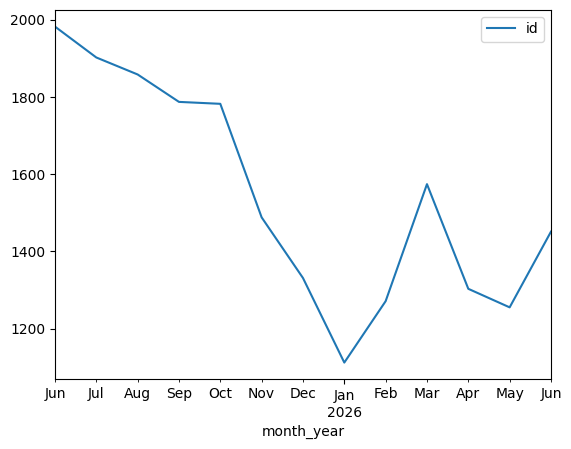

In [75]:
all_judicial_communications_rjs.plot(x='month_year', y='id')

In [80]:
#to compare with all database
all_judicial_communications = df.groupby('month_year')['id'].count().reset_index()
all_judicial_communications

,month_year,id
0,2025-06,21367
1,2025-07,20349
2,2025-08,22739
3,2025-09,20172
4,2025-10,20002
5,2025-11,16058
6,2025-12,14017
7,2026-01,12523
8,2026-02,16441
9,2026-03,20379


<Axes: xlabel='month_year'>

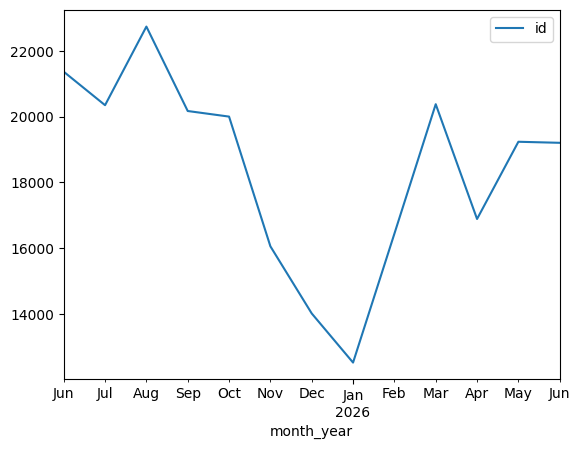

In [81]:
all_judicial_communications.plot(x='month_year', y='id')

In [82]:
all_judicial_communications.to_csv('graphs/all_judicial_communications.csv', index=False)

In [ ]:
rjs['ativo'].count()
#all cases are active

np.int64(20096)

In [85]:
df['ativo'].count()

np.int64(239378)

In [86]:
rjs['tipoDocumento'].unique()

<ArrowStringArray>
['Intimação', 'DESPACHO/DECISÃO', 'Ato ordinatório', 'Sentença']
Length: 4, dtype: str

In [113]:
tipo_documento_rjs = rjs['tipoDocumento'].value_counts().reset_index()
tipo_documento_rjs.to_csv('graphs/tipo_documento_rjs.csv', index=False)
tipo_documento_rjs

,tipoDocumento,count
0,Intimação,19722
1,Ato ordinatório,248
2,DESPACHO/DECISÃO,84
3,Sentença,42


In [112]:
tipo_documento_all = df['tipoDocumento'].value_counts().reset_index()
tipo_documento_all.to_csv('graphs/tipo_documento_all.csv', index=False)
tipo_documento_all

,tipoDocumento,count
0,Intimação,165271
1,Despacho,17259
2,DESPACHO/DECISÃO,15318
3,Intimação de acórdão,9723
4,Ato ordinatório,9443
5,Entrados,7818
6,Distribuídos,7503
7,Sentença,3711
8,VISTA,1753
9,Outros,483


## 'sentenças' (decision of merit) in restructuring cases

In [89]:
sentenças_rjs = rjs[rjs['tipoDocumento'] == 'Sentença']
sentenças_rjs.head(5)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
110023,457957130,2025-11-10,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4056159-12.2025.8....,40561591220258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Sentença,True,"[{'nome': 'JEFFERSON RIBEIRO DE PAIVA', 'comun...","[{'id': 785682012, 'comunicacao_id': 457957130...",[JEFFERSON RIBEIRO DE PAIVA],2025,11,2025-11
114363,464079007,2025-11-17,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4054794-20.2025.8....,40547942020258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Sentença,True,"[{'nome': 'ANA CAROLINA MIRANDA DANTAS NUNES',...","[{'id': 798647017, 'comunicacao_id': 464079007...","[ANA CAROLINA MIRANDA DANTAS NUNES, ANA MARIA ...",2025,11,2025-11
135196,497965905,2026-01-08,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4052270-50.2025.8....,40522705020258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Sentença,True,"[{'comunicacao_id': 497965905, 'nome': 'GAMA C...","[{'id': 871202224, 'comunicacao_id': 497965905...",[GAMA COMERCIO DE TECIDOS E CONFECCOES LTDA],2026,1,2026-01
138265,503943279,2026-01-16,Intimação,Vara Reg. Comp. Empresarial e Conflitos à Arbi...,103589,<b>Recuperação Judicial Nº 4000040-85.2025.8....,40000408520258260373,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Sentença,True,"[{'comunicacao_id': 503943279, 'nome': 'EDVALD...","[{'id': 883395892, 'comunicacao_id': 503943279...","[EDVALDO FRANCISCO PIRES, PIRES-MATERIAIS DE C...",2026,1,2026-01
138338,504071008,2026-01-16,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,<b>Recuperação Judicial Nº 4069110-38.2025.8....,40691103820258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Sentença,True,"[{'comunicacao_id': 504071008, 'nome': 'ACROP ...","[{'id': 883646733, 'comunicacao_id': 504071008...","[ACROP SERVICOS EM MOVEIS E DECORACOES LTDA, A...",2026,1,2026-01


In [90]:
sentenças_rjs['company_A'].value_counts()

company_A
[CAIQUE MATURANO DE SOUZA, CCMR COMERCIO DE DOCES E FAST FOOD LTDA, CCRRG COMERCIO DE DOCES LTDA, FABRICA MATURANO INDUSTRIA E COMERCIO DE PANIFICACAO LTDA, JOANINHA COMERCIO DE DOCES LTDA, LH COMERCIO DE DOCES LTDA, LKM COMERCIO DE DOCES LTDA, MATURANO & MATURANO COMERCIO DE DOCES E FAST FOOD LTDA, MATURANO COMERCIO DE DOCES E CONFEITES LTDA, MATURANO E BRANDAO COMERCIO DE DOCES E FAST FOOD LTDA, O TRADICIONALISSIMO COMERCIO DE DOCES E  FAST FOOD LTDA, SBS COMERCIO DE DOCES LTDA]    2
[LOG LIX SERVICOS E AMBIENTAL LTDA]                                                                                                                                                                                                                                                                                                                                                                                                                                                                      2
[JEFFERS

In [ ]:
sentenças_rjs.to_csv('subsets_raw/sentenças_rjs.csv')
#since it was only 42, I looked at the decisions with spreadsheets by opening the links (cloudfare)

In [114]:
sentenças_rjs.loc[110023, 'texto']

'<b>Recuperação Judicial  Nº 4056159-12.2025.8.26.0100/SP</b></br><b><table border="0"><tr><td>AUTOR</td><td>: JEFFERSON RIBEIRO DE PAIVA</td></tr><tr><td>ADVOGADO(A)</td><td>: NELSON APARECIDO JUNIOR (OAB SP100928)</td></tr></table></b></br><p align="center">SENTENÇA</p></br>Homologo a desistência da ação e julgo extinto o processo sem resolução de mérito (CPC, art. 485, inc. VIII). Transitada em julgado, proceda-se ao arquivamento definitivo, sem cobrança de custas (STJ, AREsp 1.442.134-SP, Rel. Min. Gurgel de Faria, j. 17/11/20).'

In [179]:
sentenças_rjs_handcoded = pd.read_csv('handcoded\sentenças_rjs_categorization.csv')
sentenças_rjs_handcoded

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\samue\AppData\Local\Temp\ipykernel_11788\3747868842.py:1: SyntaxWarning: invalid escape sequence '\s'
  sentenças_rjs_handcoded = pd.read_csv('handcoded\sentenças_rjs_categorization.csv')


,Unnamed: 0,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,conteudo_sentença,motivo,observação,destinatarios,destinatarioadvogados,company_A,year,month,month_year
0,110023,457957130,2025-11-10,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4056159-12.2025.8....,40561591220258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,desistência,pessoa física,"[{'nome': 'JEFFERSON RIBEIRO DE PAIVA', 'comun...","[{'id': 785682012, 'comunicacao_id': 457957130...",['JEFFERSON RIBEIRO DE PAIVA'],2025,11,2025-11
1,114363,464079007,2025-11-17,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4054794-20.2025.8....,40547942020258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,processual,itapemirim,"[{'nome': 'ANA CAROLINA MIRANDA DANTAS NUNES',...","[{'id': 798647017, 'comunicacao_id': 464079007...","['ANA CAROLINA MIRANDA DANTAS NUNES', 'ANA MAR...",2025,11,2025-11
2,135196,497965905,2026-01-08,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4052270-50.2025.8....,40522705020258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,não pagou custas,NaN,"[{'comunicacao_id': 497965905, 'nome': 'GAMA C...","[{'id': 871202224, 'comunicacao_id': 497965905...",['GAMA COMERCIO DE TECIDOS E CONFECCOES LTDA'],2026,1,2026-01
3,138265,503943279,2026-01-16,Intimação,Vara Reg. Comp. Empresarial e Conflitos à Arbi...,103589,<b>Recuperação Judicial Nº 4000040-85.2025.8....,40000408520258260373,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,falta documentação,produtor rural,"[{'comunicacao_id': 503943279, 'nome': 'EDVALD...","[{'id': 883395892, 'comunicacao_id': 503943279...","['EDVALDO FRANCISCO PIRES', 'PIRES-MATERIAIS D...",2026,1,2026-01
4,138338,504071008,2026-01-16,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,<b>Recuperação Judicial Nº 4069110-38.2025.8....,40691103820258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,desistência,"2 meses depois, não concedeu justiça gratuita","[{'comunicacao_id': 504071008, 'nome': 'ACROP ...","[{'id': 883646733, 'comunicacao_id': 504071008...","['ACROP SERVICOS EM MOVEIS E DECORACOES LTDA',...",2026,1,2026-01
5,148079,518516067,2026-02-02,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<b>Recuperação Judicial Nº 4047260-25.2025.8....,40472602520258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,habilitação de crédito,NaN,NaN,"[{'comunicacao_id': 518516067, 'nome': 'ALANA ...","[{'id': 917315437, 'comunicacao_id': 518516067...",['ALANA DOS SANTOS MACHADO'],2026,2,2026-02
6,153943,528970005,2026-02-11,Intimação,Cartório da 1ª e 2ª Vara Reg. de Comp. Empresa...,103657,<b>Recuperação Judicial Nº 4003429-09.2025.8....,40034290920258260590,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,falta documentação,"4 meses depois, não chegou a ser deferido","[{'comunicacao_id': 528970005, 'nome': 'MRX CO...","[{'id': 944033504, 'comunicacao_id': 528970005...",['MRX CONSTRUTORA E COMERCIO LTDA'],2026,2,2026-02
7,157896,534939450,2026-02-20,Intimação,2ª Vara de Falências e Recuperações Judiciais ...,98074,<b>Recuperação Judicial Nº 4040497-08.2025.8....,40404970820258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,falta documentação,NaN,"[{'comunicacao_id': 534939450, 'nome': 'CAIQUE...","[{'id': 956766534, 'comunicacao_id': 534939450...","['CAIQUE MATURANO DE SOUZA', 'CCMR COMERCIO DE...",2026,2,2026-02
8,158600,536003560,2026-02-20,Intimação,1ªVara Reg. Comp. Empresarial e Conflitos à Ar...,103588,<b>Recuperação Judicial Nº 4017024-48.2025.8....,40170244820258260114,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,extinto,falta documentação,não chegou a ser deferido,"[{'comunicacao_id': 536003560, 'nome': 'JBR CO...","[{'id': 959118335, 'comunicacao_id': 536003560...",['JBR COZINHA INDUSTRIAL LTDA'],2026,2,2026-02
9,1593

In [182]:
analise_sentenças_rjs = sentenças_rjs_handcoded.groupby('conteudo_sentença')['motivo'].value_counts().reset_index()
analise_sentenças_rjs.to_csv('graphs/analise_sentenças_rjs.csv', index=False)
analise_sentenças_rjs

,conteudo_sentença,motivo,count
0,extinto,falta documentação,12
1,extinto,não pagou custas,8
2,extinto,desistência,7
3,extinto,processual,4
4,extinto,falta documentação + não pagou custas,1
5,extinto,falta de operação,1
6,extinto,operação antes de 1 ano e entidade sem fins lu...,1
7,extinto,fraude,1
8,homologada desistência,do recurso de apelação contra extinção do proc...,1
9,indeferido o pedido,pedido de falência por execução trabalhista,1


In [184]:
analise_sentenças_rjs_geral = sentenças_rjs_handcoded['conteudo_sentença'].value_counts().reset_index()
analise_sentenças_rjs_geral.to_csv('graphs/analise_sentenças_rjs_geral.csv', index=False)
analise_sentenças_rjs_geral

,conteudo_sentença,count
0,extinto,35
1,habilitação de crédito,5
2,indeferido o pedido,1
3,homologada desistência,1


In [251]:
sentenças_rjs_handcoded.groupby('conteudo_sentença')['month_year'].value_counts().reset_index()

,conteudo_sentença,month_year,count
0,extinto,2026-03,9
1,extinto,2026-05,6
2,extinto,2026-06,6
3,extinto,2026-04,5
4,extinto,2026-02,4
5,extinto,2026-01,3
6,extinto,2025-11,2
7,habilitação de crédito,2026-03,2
8,habilitação de crédito,2026-02,1
9,habilitação de crédito,2026-05,1


In [254]:
extintos = sentenças_rjs_handcoded[sentenças_rjs_handcoded['conteudo_sentença'] == 'extinto']
extintos.shape

(35, 18)

In [301]:
extintos.to_csv('subsets_raw/extintos.csv')

In [ ]:
extintos.groupby('conteudo_sentença')['year'].value_counts().reset_index()
#getting the case that repeats

,conteudo_sentença,year,count
0,extinto,2026,33
1,extinto,2025,2


In [257]:
extintos.groupby('conteudo_sentença')['month_year'].value_counts().reset_index()

,conteudo_sentença,month_year,count
0,extinto,2026-03,9
1,extinto,2026-05,6
2,extinto,2026-06,6
3,extinto,2026-04,5
4,extinto,2026-02,4
5,extinto,2026-01,3
6,extinto,2025-11,2


In [274]:
extintos.columns

Index(['Unnamed: 0', 'id', 'data_disponibilizacao', 'tipoComunicacao',
       'nomeOrgao', 'idOrgao', 'texto', 'numero_processo', 'link',
       'conteudo_sentença', 'motivo', 'observação', 'destinatarios',
       'destinatarioadvogados', 'company_A', 'year', 'month', 'month_year'],
      dtype='str')

In [ ]:
extintos['id'].nunique()

35

In [278]:
extintos['numero_processo'].nunique()

34

In [ ]:
extintos.groupby('month_year')['numero_processo'].nunique().sort_index()
#this is not getting the unique cases

month_year
2025-11    2
2026-01    3
2026-02    4
2026-03    9
2026-04    5
2026-05    6
2026-06    6
Name: numero_processo, dtype: int64

In [315]:
extintos['numero_processo'].value_counts()

numero_processo
40404970820258260100    2
40561591220258260100    1
40547942020258260100    1
40522705020258260100    1
40000408520258260373    1
40691103820258260100    1
40034290920258260590    1
40170244820258260114    1
40000618420268260354    1
40003224920268260354    1
40055216520268260576    1
40423159220258260100    1
40814423720258260100    1
40765144320258260100    1
40001795120268260260    1
40001812120268260260    1
40001189320268260260    1
40774670720258260100    1
40000197520268260373    1
40237356920258260114    1
40001971820258260354    1
40000270320268260260    1
40390513320268260100    1
40749442220258260100    1
40533444220258260100    1
40001139520268260252    1
40091775820268260114    1
40390825320268260100    1
40140253320268260100    1
40751390720258260100    1
40932388820268260100    1
40003093520268260359    1
40094431720268260576    1
40019651320268260590    1
Name: count, dtype: int64

In [320]:
proc_unicos_globais = extintos['numero_processo'].unique()
#counting the case only once

In [321]:
len(proc_unicos_globais)

34

In [322]:
(extintos[extintos['numero_processo'].isin(proc_unicos_globais)]
        .groupby('month_year')['numero_processo']
        .count()
        .sort_index())

month_year
2025-11    2
2026-01    3
2026-02    4
2026-03    9
2026-04    5
2026-05    6
2026-06    6
Name: numero_processo, dtype: int64

In [324]:
extintos.shape

(35, 18)

In [326]:
extintos.drop_duplicates('numero_processo')
extintos.shape

(35, 18)

In [323]:
(extintos[extintos['numero_processo'].isin(proc_unicos_globais)]
        .groupby('year')['numero_processo']
        .count()
        .sort_index())

year
2025     2
2026    33
Name: numero_processo, dtype: int64

In [ ]:
repetidos = (
    extintos['numero_processo']
        .value_counts()
        .loc[lambda x: x > 1]
)
repetidos
#cases that repeats

numero_processo
40404970820258260100    2
Name: count, dtype: int64

In [330]:
extintos_34 = extintos[~extintos['numero_processo'].isin(repetidos)]

In [331]:
len(extintos_34)

35

In [298]:
extintos_year = extintos.groupby('year')['numero_processo'].nunique().sort_index()
extintos_year.to_csv('graphs/extintos.csv')
extintos_year

year
2025     2
2026    32
Name: numero_processo, dtype: int64

In [299]:
extintos.groupby('conteudo_sentença')['motivo'].value_counts().reset_index()

,conteudo_sentença,motivo,count
0,extinto,falta documentação,12
1,extinto,não pagou custas,8
2,extinto,desistência,7
3,extinto,processual,4
4,extinto,falta documentação + não pagou custas,1
5,extinto,falta de operação,1
6,extinto,operação antes de 1 ano e entidade sem fins lu...,1
7,extinto,fraude,1


In [303]:
proc_unicos_globais.nunique()

33

In [300]:
(extintos[extintos['numero_processo'].isin(proc_unicos_globais)]
                .groupby('conteudo_sentença')['motivo']
                .value_counts()
                .reset_index())

,conteudo_sentença,motivo,count
0,extinto,falta documentação,10
1,extinto,não pagou custas,8
2,extinto,desistência,7
3,extinto,processual,4
4,extinto,falta documentação + não pagou custas,1
5,extinto,falta de operação,1
6,extinto,operação antes de 1 ano e entidade sem fins lu...,1
7,extinto,fraude,1


## 'despacho/decisão' (common decision) in restructuring cases

In [115]:
despachos_rjs = rjs[rjs['tipoDocumento'] == 'DESPACHO/DECISÃO']
despachos_rjs.head(5)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
101786,446846398,2025-10-28,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40494575020258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,[{'nome': 'MARIA IVANUSIA SOARES MIRANDA PEREI...,"[{'id': 762149225, 'comunicacao_id': 446846398...",[MARIA IVANUSIA SOARES MIRANDA PEREIRA],2025,10,2025-10
103160,448395158,2025-10-30,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40483523820258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,[{'nome': 'CENTURION SEGURANCA E VIGILANCIA LT...,"[{'id': 765577512, 'comunicacao_id': 448395158...",[HENRIQUE PAULO DOS SANTOS],2025,10,2025-10
104598,450444630,2025-10-31,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40509990620258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,[{'nome': 'CAPITAL ADMINISTRADORA JUDICIAL LTD...,"[{'id': 769932856, 'comunicacao_id': 450444630...",[LALESCA ELAINE DOS SANTOS],2025,10,2025-10
106463,452919099,2025-11-04,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40545733720258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,[{'nome': 'DELOITTE TOUCHE TOHMATSU CONSULTORE...,"[{'id': 775012855, 'comunicacao_id': 452919099...",[DIEGO CORREA DE ABREU],2025,11,2025-11
107261,454182832,2025-11-05,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40507358620258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,"[{'nome': 'CARLOS HENRIQUE PORTES', 'comunicac...","[{'id': 777718250, 'comunicacao_id': 454182832...",[CARLOS HENRIQUE PORTES],2025,11,2025-11


In [120]:
despachos_rjs['company_A'].value_counts()

company_A
[IGPECOGRAPH INDUSTRIA METALURGICA LTDA - EM RECUPERACAO JUDICIAL]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [121]:
despachos_rjs.to_csv('subsets_raw/despachos_rjs.csv')

In [126]:
despachos_rjs['texto'].dtype

<StringDtype(na_value=nan)>

In [129]:
despachos_rjs.loc[101786, 'texto']

'<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style></style>\n\t</head>\n\t<body>\n\t\t<article>\n\t\t\t\n\n\n\n\n\n\n\n\n\n\n\n<header>\n\t\t\t\t<div></div> \n\t\t\t\t \n\t\t\t\t \n\t\t\t\t \n\t\t\t\t \t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t</header>\n<section><b>Recupera&ccedil;&atilde;o Judicial  N&ordm; 4049457-50.2025.8.26.0100/SP</b></section>\n<section><b><table><tr><td>AUTOR</td><td>: MARIA IVANUSIA SOARES MIRANDA PEREIRA</td></tr><tr><td>ADVOGADO(A)</td><td>: ALINE RAMOS BARROS (OAB CE030837)</td></tr><tr><td>R&Eacute;U</td><td>: NOSSA ELETRO S.A. EM RECUPERACAO JUDICIAL</td></tr><tr><td>ADVOGADO(A)</td><td>: PEDRO HENRIQUE TORRES BIANCHI (OAB SP259740)</td></tr><tr><td>ADVOGADO(A)</td><td>: GIOVANNA MICHELLETO (OAB SP418667)</td></tr></table></b></section>\n<section>\n\t\t\t\t<p align="center">DESPACHO/DECIS&Atilde;O</p>\n\t\t\t</section>\n<section>\n<p>Concedo a gratuidade da justi&ccedil;a.</p>\n<p>Intime-se o requerido para contesta&ccedil;&atilde;o em cinco dias.</p>\n<p>Em seg

## regex to analyse the court decisions

In [133]:
#seeing how many are in a html format in rjs
rjs['texto'].str.startswith('<html>', na=False).value_counts()

texto
False    19978
True       118
Name: count, dtype: int64

In [135]:
#seeing how many are in a html format in this subset
#using regex to identify all html tags (not only that starts with html)

rjs['texto'].str.contains(
    r'<[a-zA-Z][^>]*>',
    regex=True,
    na=False
).value_counts()

texto
False    19717
True       379
Name: count, dtype: int64

In [137]:
##first, cleaning the texts that are html (created a function)

def limpar_html(texto):
    soup = BeautifulSoup(texto, "html.parser")
    return soup.get_text(separator=" ", strip=True)

In [138]:
rjs['texto_limpo'] = rjs['texto'].apply(limpar_html)

In [145]:
#normalize some characteres in the html
rjs['texto_limpo'] = rjs['texto_limpo'].apply(html.unescape)

In [147]:
#removing white spaces

rjs['texto_limpo'] = (
    rjs['texto_limpo']
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
)

In [150]:
#certifying that the cleaning worked 

for i in rjs.index[:50]:
    print("----------------------------------------------------------")
    print("ORIGINAL:")
    print(rjs.loc[i, "texto"][:500])

    print("\nLIMPO:")
    print(rjs.loc[i, "texto_limpo"][:500])

----------------------------------------------------------
ORIGINAL:
Processo 1014762-13.2014.8.26.0196 - Recuperação Judicial - Recuperação judicial e Falência - MEDICAL PÉ INDÚSTRIA E COMÉRCIO DE CALÇADOS LTDA. -  - MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA  - Ernesto Volpe Filho  - Banco Itau - Unibanco S/A -  - Passalacqua Indústria e Comércio Ltda -  - ADRIENE MIRELY DE PAULA SOUZA -  - Componew Compnentes para Calçados Ltda -  - CURTUME COBRASIL LTDA -  - CAIXA ECONÔMICA FEDERAL -  - BEÉRRE ASSESSORIA EMPRESARIAL LTDA -  - SANDRA AUGUSTA RIBEIRO SANTOS -  - Eliz

LIMPO:
Processo 1014762-13.2014.8.26.0196 - Recuperação Judicial - Recuperação judicial e Falência - MEDICAL PÉ INDÚSTRIA E COMÉRCIO DE CALÇADOS LTDA. - - MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA - Ernesto Volpe Filho - Banco Itau - Unibanco S/A - - Passalacqua Indústria e Comércio Ltda - - ADRIENE MIRELY DE PAULA SOUZA - - Componew Compnentes para Calçados Ltda - - CURTUME COBRASIL LTDA - - CAIXA ECONÔMICA FEDERAL - - BEÉRRE ASS

In [155]:
rjs['texto_limpo'].dtype

<StringDtype(na_value=nan)>

In [156]:
#### regex

padroes = {
    "defiro": r"\bdefiro\b",

    "recuperacao_judicial":
        r"\bdefiro\b.*?\brecuperação judicial\b",

    "processamento_rj":
        r"\bdefiro\b.*?\bprocessamento\b.*?\brecuperação judicial\b",

    "tutela_cautelar":
        r"\bdefiro\b.*?\btutela cautelar antecedente\b",

    "antecipacao_tutela":
        r"\bantecipação da tutela\b"
}

for nome, regex in padroes.items():
    rjs[nome] = rjs['texto_limpo'].str.contains(
        regex,
        case=False,
        na=False
    )

In [171]:
rjs.head(20)

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,...,company_A,year,month,month_year,texto_limpo,defiro,recuperacao_judicial,processamento_rj,tutela_cautelar,antecipacao_tutela
36,285040995,2025-06-02,Intimação,Foro de Franca - 5ª Vara Cível,92004,Processo 1014762-13.2014.8.26.0196 - Recuperaç...,10147621320148260196,https://www.dje.tjsp.jus.br,Intimação,True,...,"[MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA, MEDICAL...",2025,6,2025-06,Processo 1014762-13.2014.8.26.0196 - Recuperaç...,False,False,False,False,False
65,285063561,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0028361-79.1996.8.26.0224 (224.01.199...,283617919968260224,https://www.dje.tjsp.jus.br,Intimação,True,...,[BANCO MARKA S/A],2025,6,2025-06,Processo 0028361-79.1996.8.26.0224 (224.01.199...,False,False,False,False,False
71,285068365,2025-06-02,Intimação,Foro de Guarulhos - 7ª Vara Cível,70990,Processo 0018306-11.1992.8.26.0224 (224.01.199...,183061119928260224,https://www.dje.tjsp.jus.br,Intimação,True,...,[ROTOPACK EMBALAGENS FLEXIVEIS LTDA.],2025,6,2025-06,Processo 0018306-11.1992.8.26.0224 (224.01.199...,False,False,False,False,False
90,285091252,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1024035-88.2024.8.26.0576 - Recuperaç...,10240358820248260576,https://www.dje.tjsp.jus.br,Intimação,True,...,"[RAMOS & SILVA SOLUÇÕES DIGITAIS LTDA, RAMOS &...",2025,6,2025-06,Processo 1024035-88.2024.8.26.0576 - Recuperaç...,False,False,False,False,False
96,285093632,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000607-49.2024.8.26.0359 - Recuperaç...,10006074920248260359,https://www.dje.tjsp.jus.br,Intimação,True,...,[PADRãO INDUSTRIA DE CHARQUE LTDA],2025,6,2025-06,Processo 1000607-49.2024.8.26.0359 - Recuperaç...,False,False,False,False,False
98,285093891,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1001174-80.2024.8.26.0359 - Recuperaç...,10011748020248260359,https://www.dje.tjsp.jus.br,Intimação,True,...,"[PRO-RIVER SERVICOS DE AUDIO LTDA, RIVER MUSIC...",2025,6,2025-06,Processo 1001174-80.2024.8.26.0359 - Recuperaç...,False,False,False,False,False
106,285096516,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000586-73.2024.8.26.0359 - Recuperaç...,10005867320248260359,https://www.dje.tjsp.jus.br,Intimação,True,...,"[BRASPEN LOGíSTICA LTDA, ORGANOCAMPO COMéRCIO ...",2025,6,2025-06,Processo 1000586-73.2024.8.26.0359 - Recuperaç...,False,False,False,False,False
159,285109060,2025-06-02,Intimação,Foro de Piracicaba - 6ª Vara Cível,70659,Processo 1019928-85.2024.8.26.0451 - Recuperaç...,10199288520248260451,https://www.dje.tjsp.jus.br,Intimação,True,...,[CERBA DESTILARIA DE ALCOOL LTDA - EM RECUPERA...,2025,6,2025-06,Processo 1019928-85.2024.8.26.0451 - Recuperaç...,True,True,False,False,False
177,285118617,2025-06-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1010151-89.2024.8.26.0576 - Recuperaç...,10101518920248260576,https://www.dje.tjsp.jus.br,Intimação,True,...,[MERCEARIA NOZABIELI LTDA],2025,6,2025-06,Processo 1010151-89.2024.8.26.0576 - Recuperaç...,False,False,False,False,False
248,285270848,2025-06-02,Intimação,Foro de Presidente Prudente - 5ª Vara Cível,91822,Processo 1008857-03.2018.8.26.0482 - Recuperaç...,10088570320188260482,https://www.dje.tjsp.jus.br,Intimação,True,...,[ATTROS EQUIPAMENTOS FITNESS],2025,6,2025-06,Processo 1008857-03.2018.8.26.0482 - Recuperaç...,False,False,False,False,False


In [176]:
rjs[['defiro', 'recuperacao_judicial', 'processamento_rj', 'tutela_cautelar', 'antecipacao_tutela']].value_counts()

defiro  recuperacao_judicial  processamento_rj  tutela_cautelar  antecipacao_tutela
False   False                 False             False            False                 17951
True    False                 False             False            False                  1309
        True                  False             False            False                   591
                              True              False            False                   163
False   False                 False             False            True                     24
True    True                  True              False            True                     24
                              False             False            True                     20
                                                True             False                     4
                              True              True             True                      4
                                                                 False         

In [161]:
rjs[rjs['tutela_cautelar'] == True]

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,...,company_A,year,month,month_year,texto_limpo,defiro,recuperacao_judicial,processamento_rj,tutela_cautelar,antecipacao_tutela
15663,304054285,2025-06-23,Intimação,Foro Central Cível - 1ª Vara de Falências e Re...,97202,Processo 1080871-98.2017.8.26.0100 - Recuperaç...,10808719820178260100,https://www.dje.tjsp.jus.br,Intimação,True,...,None,2025,6,2025-06,Processo 1080871-98.2017.8.26.0100 - Recuperaç...,True,True,False,True,False
15673,304064798,2025-06-23,Intimação,Foro Central Cível - 1ª Vara de Falências e Re...,97202,Processo 1080871-98.2017.8.26.0100 - Recuperaç...,10808719820178260100,https://www.dje.tjsp.jus.br,Intimação,True,...,None,2025,6,2025-06,Processo 1080871-98.2017.8.26.0100 - Recuperaç...,True,True,False,True,False
29483,325026601,2025-07-15,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000272-93.2025.8.26.0359 - Recuperaç...,10002729320258260359,NaN,Intimação,True,...,"[ANGELICA KARINE PARTICIPACOES LTDA, MERCADO D...",2025,7,2025-07,Processo 1000272-93.2025.8.26.0359 - Recuperaç...,True,True,False,True,False
32959,328843925,2025-07-18,Intimação,Foro Central Cível - 1ª Vara de Falências e Re...,97202,Processo 1101129-56.2022.8.26.0100 - Recuperaç...,11011295620228260100,NaN,Intimação,True,...,[JETIRANA EMPREENDIMENTOS S/A],2025,7,2025-07,Processo 1101129-56.2022.8.26.0100 - Recuperaç...,True,True,True,True,False
44440,343717405,2025-08-05,Intimação,Foro Central Cível - 1ª Vara de Falências e Re...,97202,Processo 1103449-74.2025.8.26.0100 - Recuperaç...,11034497420258260100,NaN,Intimação,True,...,[BRASIL BIO FUELS S/A],2025,8,2025-08,Processo 1103449-74.2025.8.26.0100 - Recuperaç...,True,True,True,True,True
66196,368148856,2025-09-02,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1000766-55.2025.8.26.0359 - Recuperaç...,10007665520258260359,NaN,Intimação,True,...,"[CEREALISTA TROVA LTDA, CLELIA CRISTINA DOS SA...",2025,9,2025-09,Processo 1000766-55.2025.8.26.0359 - Recuperaç...,True,True,True,True,True
92518,432830482,2025-10-13,Intimação,Foro Central Cível - 2ª Vara de Falências e Re...,97230,Processo 1115045-55.2025.8.26.0100 - Recuperaç...,11150455520258260100,https://www.dje.tjsp.jus.br,Intimação,True,...,"[COMPANHIA BRASILEIRA DE ESTIRENO - CBE, ECOHY...",2025,10,2025-10,Processo 1115045-55.2025.8.26.0100 - Recuperaç...,True,True,True,True,False
102848,447937992,2025-10-29,Intimação,Foro Central Cível - 1ª Vara de Falências e Re...,97202,Processo 1080871-98.2017.8.26.0100 - Recuperaç...,10808719820178260100,https://www.dje.tjsp.jus.br,Intimação,True,...,None,2025,10,2025-10,Processo 1080871-98.2017.8.26.0100 - Recuperaç...,True,True,False,True,False
107494,454540310,2025-11-06,Intimação,"Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...",92802,Processo 1034974-93.2025.8.26.0576 - Recuperaç...,10349749320258260576,https://www.dje.tjsp.jus.br,Intimação,True,...,"[AMERICANFLEX INDS REUNIDAS LT, AMX COLCHõES M...",2025,11,2025-11,Processo 1034974-93.2025.8.26.0576 - Recuperaç...,True,True,True,True,True
132654,492240131,2025-12-18,Intimação,Foro Central Cível - 2ª Vara de Falências e Re...,97230,Processo 1115045-55.2025.8.26.0100 - Recuperaç...,11150455520258260100,https://www.dje.tjsp.jus.br,Intimação,True,...,[UNIGEL DISTRIBUIDORA S.A.],2025,12,2025-12,Processo 1115045-55.2025.8.26.0100 - Recuperaç...,True,False,False,True,False


In [165]:
rjs.loc[171621, 'texto_limpo']

'Processo 1092481-82.2025.8.26.0100 - Recuperação Judicial - Recuperação judicial e Falência - Promaflex Industrial Ltda - Fernando Celso de Aquino Chad - Vistos. Fls. 3559/3560: última decisão 1) Fls. 3570; 3573; 3580; 3585; 3589; 3593; 3726; 3728; 3777; 3782; 3787; 3812; 3792; 4834/4835; 4842/4843; 4906/4907; 5224/5225; 5254; 5259; 6135; 6137; 6171; 6185; 6191; 6202/6203; 6236/6237; 6.308; 6.412 (Credores regularizam representação processual e solicitam habilitação nos autos): À z. Serventia para anotações. 2) Fls. 3571/3572 (Banco Bradesco solicita dilação de prazo de 10 dias úteis para finalizar análise de descontos e apresentar comprovante de estorno para a Recuperanda): Defiro. 3) Fls. 3668; 3679/3680; 3687/3688; 3734/3735; 3744/3745; 5199/5202; 5229; 5246/5249 (Credores apresentam pedido de habilitação de crédito): As habilitações de crédito devem ser apresentadas em incidente próprio, distribuído por dependência aos autos da recuperação judicial, conforme Comunicado Geral CG 21

In [ ]:
rjs.loc[146434, 'texto_limpo']
## accepted the judicial reorganization

'Processo 1000845-34.2025.8.26.0359 - Recuperação Judicial - Recuperação judicial e Falência - Pavit Construtora Ltda. - Banco Volvo Brasil S/A - - Banco Caterpillar S/A - - Deutsche Sparkassen Leasing do Brasil S/A – Sociedade de Arrendamento Mercantil - RODRIGUES & ZANCHETTA ADMINISTRACAO DE FALENCIAS E EMPRESAS - Vistos processo nº 1000845-34.2025.8.26.26.0359 1 Trata-se depedido de tutela cautelar em caráter antecedenteformulado por PAVIT CONSTRUTORA LTDA CNPJ nº 23.686.592/0001-42 qualificada nos autos, com sede em São José do Rio Preto/SP. 2 O pedido está fundamentado no artigo 6º, § 12º, da Lei nº 11.101/05 (LRF), assim como nos artigos 300 e seguintes do Código de Processo Civil. 3 Deferida a antecipação da tutela para suspensão das execuções e medidas de constrição contra a requente, com antecipação do stay period, foi determinada a constatação prévia, destinada a analisar as reais condições de funcionamento da empresa e a regularidade documental. 4 Pela empresa nomeada perita

In [236]:
rjs.loc[146434]

id                                                                  516114182
data_disponibilizacao                                     2026-01-30 00:00:00
tipoComunicacao                                                     Intimação
nomeOrgao                   Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...
idOrgao                                                                 92802
texto                       Processo 1000845-34.2025.8.26.0359 - Recuperaç...
numero_processo                                          10008453420258260359
link                                              https://www.dje.tjsp.jus.br
tipoDocumento                                                       Intimação
ativo                                                                    True
destinatarios               [{'comunicacao_id': 516114182, 'nome': 'PAVIT ...
destinatarioadvogados       [{'id': 912144982, 'comunicacao_id': 516114182...
company_A                                           [PAVIT CONST

In [ ]:
rjs.loc[140348, 'texto_limpo']
#same case as above


'Processo 1000845-34.2025.8.26.0359 - Recuperação Judicial - Recuperação judicial e Falência - Pavit Construtora Ltda. - Banco Volvo Brasil S/A - - Banco Caterpillar S/A - - Deutsche Sparkassen Leasing do Brasil S/A – Sociedade de Arrendamento Mercantil - RODRIGUES & ZANCHETTA ADMINISTRACAO DE FALENCIAS E EMPRESAS - Vistos processo nº 1000845-34.2025.8.26.26.0359 1 Trata-se depedido de tutela cautelar em caráter antecedenteformulado por PAVIT CONSTRUTORA LTDA CNPJ nº 23.686.592/0001-42 qualificada nos autos, com sede em São José do Rio Preto/SP. 2 O pedido está fundamentado no artigo 6º, § 12º, da Lei nº 11.101/05 (LRF), assim como nos artigos 300 e seguintes do Código de Processo Civil. 3 Em 22/09/2025 foi deferida a tutela para suspensão de ações e execuções em face da empresa PAVIT CONSTRUTORA LTDA conforme decisão de fl. 254. 4 Em 09/12/2025 foi prorrogada, por mais 60 dias, as tutelas cautelares anteriormente deferidas, ressalvados os casos em que credores obtiveram suspensão da m

In [336]:
padrao_deferimento_rj = r"Defiro\s+o\s+processamento\s+da\s+recuperação\s+judicial\.?"

rjs['resultado_rj_deferimento'] = (rjs['texto_limpo'].str.contains(padrao_deferimento_rj, case=False, na=False, regex=True))

In [ ]:
resultado_rj_deferimento = rjs[rjs['resultado_rj_deferimento'] == True]
resultado_rj_deferimento
#caught words that don't start with "defiro". caught sentenças which said "indefiro"

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,...,month,month_year,texto_limpo,defiro,recuperacao_judicial,processamento_rj,tutela_cautelar,antecipacao_tutela,resultado_re_deferimento,resultado_rj_deferimento
2273,288553081,2025-06-04,Intimação,Foro Especializado das 3ª e 6ª RAJs - Vara Reg...,91967,Processo 1003974-91.2025.8.26.0506 - Recuperaç...,10039749120258260506,https://www.dje.tjsp.jus.br,Intimação,True,...,6,2025-06,Processo 1003974-91.2025.8.26.0506 - Recuperaç...,True,True,True,False,False,True,True
3651,289622684,2025-06-05,Intimação,Foro Central Cível - 2ª Vara de Falências e Re...,97230,Processo 1047518-86.2025.8.26.0100 - Recuperaç...,10475188620258260100,https://www.dje.tjsp.jus.br,Intimação,True,...,6,2025-06,Processo 1047518-86.2025.8.26.0100 - Recuperaç...,True,True,True,False,False,True,True
6311,292492199,2025-06-09,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 1ª V...,70539,Processo 1001446-46.2025.8.26.0260 - Recuperaç...,10014464620258260260,https://www.dje.tjsp.jus.br,Intimação,True,...,6,2025-06,Processo 1001446-46.2025.8.26.0260 - Recuperaç...,True,True,True,False,False,True,True
6916,293334320,2025-06-09,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 2ª V...,71280,Processo 1007689-97.2025.8.26.0068 - Recuperaç...,10076899720258260068,https://www.dje.tjsp.jus.br,Intimação,True,...,6,2025-06,Processo 1007689-97.2025.8.26.0068 - Recuperaç...,True,True,True,False,False,True,True
9067,294666598,2025-06-10,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 1ª V...,70539,Processo 1005460-09.2025.8.26.0152 - Recuperaç...,10054600920258260152,https://www.dje.tjsp.jus.br,Intimação,True,...,6,2025-06,Processo 1005460-09.2025.8.26.0152 - Recuperaç...,True,True,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172043,557109150,2026-03-13,Intimação,Foro Especializado das 3ª e 6ª RAJs - Vara Reg...,91967,Processo 1001965-04.2024.8.26.0374 - Recuperaç...,10019650420248260374,https://www.dje.tjsp.jus.br,Intimação,True,...,3,2026-03,Processo 1001965-04.2024.8.26.0374 - Recuperaç...,True,True,True,False,False,True,True
175761,562426689,2026-03-18,Intimação,Cartório da 1ª e 2ª Vara Reg. de Comp. Empresa...,103657,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40005046020258260260,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,3,2026-03,Recuperação Judicial Nº 4000504-60.2025.8.26.0...,True,True,True,False,False,True,True
183049,573065224,2026-03-30,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,<b>Recuperação Judicial Nº 4074041-84.2025.8....,40740418420258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,3,2026-03,Recuperação Judicial Nº 4074041-84.2025.8.26.0...,True,True,True,False,False,True,True
194214,588329776,2026-04-17,Intimação,1ªVara Reg. Comp. Empresarial e Conflitos à Ar...,103588,<b>Recuperação Judicial Nº 4000197-18.2025.8....,40001971820258260354,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Sentença,True,...,4,2026-04,Recuperação Judicial Nº 4000197-18.2025.8.26.0...,False,False,False,False,False,True,True


In [338]:
resultado_rj_deferimento['texto_limpo'].dtype

<StringDtype(na_value=nan)>

In [339]:
resultado_rj_deferimento['numero_processo'].unique()

array([10039749120258260506, 10475188620258260100, 10014464620258260260,
       10076899720258260068, 10054600920258260152, 10354146220258260100,
       10039367520248260260, 10000200820258260354, 10000403920258260373,
       11686106520248260100, 10003500520258260354, 10545487520258260100,
       10755977520258260100, 10001396620258260354, 10443247820258260100,
       10849235920258260100, 10015244020258260260, 10000511320258260359,
       10015876520258260260, 10797289320258260100, 10014127120258260260,
       10782452820258260100, 10020014220258260073, 10002136320258260373,
       10002756320258260354, 10029242620248260260, 10039300620248260022,
       10006445720258260354, 10017816520258260260, 10241648720258260114,
       11941069620248260100, 10021185420258260260, 10005475720258260354,
       10052869720258260637, 10003837720258260359, 10222152820258260114,
       10024883320258260260, 10002794320258260373, 10005448720258260359,
       11957585120248260100, 10876395920258260100, 

In [340]:
resultado_rj_deferimento['numero_processo'].nunique()

84

In [341]:
rjs.loc[rjs['resultado_rj_deferimento'], 'texto_limpo']

2273      Processo 1003974-91.2025.8.26.0506 - Recuperaç...
3651      Processo 1047518-86.2025.8.26.0100 - Recuperaç...
6311      Processo 1001446-46.2025.8.26.0260 - Recuperaç...
6916      Processo 1007689-97.2025.8.26.0068 - Recuperaç...
9067      Processo 1005460-09.2025.8.26.0152 - Recuperaç...
                                ...                        
172043    Processo 1001965-04.2024.8.26.0374 - Recuperaç...
175761    Recuperação Judicial Nº 4000504-60.2025.8.26.0...
183049    Recuperação Judicial Nº 4074041-84.2025.8.26.0...
194214    Recuperação Judicial Nº 4000197-18.2025.8.26.0...
215299    Recuperação Judicial Nº 4000255-27.2026.8.26.0...
Name: texto_limpo, Length: 93, dtype: str

In [342]:
padrao2_deferimento_rj = r"\bDefiro o processamento da recuperação judicial\b(?:\s*,?\s*\w.*)?"
rjs['resultado_rj_deferimento_2'] = (rjs['texto_limpo'].str.contains(padrao2_deferimento_rj, case=False, na=False, regex=True))


In [347]:
rjs[rjs['resultado_rj_deferimento_2'] == True]

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,...,month_year,texto_limpo,defiro,recuperacao_judicial,processamento_rj,tutela_cautelar,antecipacao_tutela,resultado_re_deferimento,resultado_rj_deferimento,resultado_rj_deferimento_2
2273,288553081,2025-06-04,Intimação,Foro Especializado das 3ª e 6ª RAJs - Vara Reg...,91967,Processo 1003974-91.2025.8.26.0506 - Recuperaç...,10039749120258260506,https://www.dje.tjsp.jus.br,Intimação,True,...,2025-06,Processo 1003974-91.2025.8.26.0506 - Recuperaç...,True,True,True,False,False,True,True,True
3651,289622684,2025-06-05,Intimação,Foro Central Cível - 2ª Vara de Falências e Re...,97230,Processo 1047518-86.2025.8.26.0100 - Recuperaç...,10475188620258260100,https://www.dje.tjsp.jus.br,Intimação,True,...,2025-06,Processo 1047518-86.2025.8.26.0100 - Recuperaç...,True,True,True,False,False,True,True,True
6311,292492199,2025-06-09,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 1ª V...,70539,Processo 1001446-46.2025.8.26.0260 - Recuperaç...,10014464620258260260,https://www.dje.tjsp.jus.br,Intimação,True,...,2025-06,Processo 1001446-46.2025.8.26.0260 - Recuperaç...,True,True,True,False,False,True,True,True
6916,293334320,2025-06-09,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 2ª V...,71280,Processo 1007689-97.2025.8.26.0068 - Recuperaç...,10076899720258260068,https://www.dje.tjsp.jus.br,Intimação,True,...,2025-06,Processo 1007689-97.2025.8.26.0068 - Recuperaç...,True,True,True,False,False,True,True,True
9067,294666598,2025-06-10,Intimação,Foro Especializado 1ª RAJ/7ª RAJ/9ª RAJ - 1ª V...,70539,Processo 1005460-09.2025.8.26.0152 - Recuperaç...,10054600920258260152,https://www.dje.tjsp.jus.br,Intimação,True,...,2025-06,Processo 1005460-09.2025.8.26.0152 - Recuperaç...,True,True,True,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170123,554381314,2026-03-10,Intimação,Foro Especializado da 4ª e da 10ª RAJs - 1ª Va...,71169,Processo 1039881-42.2025.8.26.0114 - Recuperaç...,10398814220258260114,https://www.dje.tjsp.jus.br,Intimação,True,...,2026-03,Processo 1039881-42.2025.8.26.0114 - Recuperaç...,True,True,True,False,False,True,True,True
172043,557109150,2026-03-13,Intimação,Foro Especializado das 3ª e 6ª RAJs - Vara Reg...,91967,Processo 1001965-04.2024.8.26.0374 - Recuperaç...,10019650420248260374,https://www.dje.tjsp.jus.br,Intimação,True,...,2026-03,Processo 1001965-04.2024.8.26.0374 - Recuperaç...,True,True,True,False,False,True,True,True
175761,562426689,2026-03-18,Intimação,Cartório da 1ª e 2ª Vara Reg. de Comp. Empresa...,103657,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40005046020258260260,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2026-03,Recuperação Judicial Nº 4000504-60.2025.8.26.0...,True,True,True,False,False,True,True,True
183049,573065224,2026-03-30,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,<b>Recuperação Judicial Nº 4074041-84.2025.8....,40740418420258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2026-03,Recuperação Judicial Nº 4074041-84.2025.8.26.0...,True,True,True,False,False,True,True,True


In [ ]:
rjs[(rjs['resultado_rj_deferimento_2'] == True) & (rjs['tipoDocumento'] == "Sentença")]
#good sign

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,...,month_year,texto_limpo,defiro,recuperacao_judicial,processamento_rj,tutela_cautelar,antecipacao_tutela,resultado_re_deferimento,resultado_rj_deferimento,resultado_rj_deferimento_2


In [348]:
pd.set_option('display.max_colwidth', None)

In [349]:
rjs.loc[rjs['resultado_rj_deferimento'], 'texto_limpo']


2273                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [350]:
for texto in rjs.loc[rjs['resultado_rj_deferimento'], 'texto_limpo']:
    print("\n--- DECISÃO ---\n")
    print(texto)


--- DECISÃO ---

Processo 1003974-91.2025.8.26.0506 - Recuperação Judicial - Liminar - PASSAREDO TRANSPORTES AÉREOS - - Map Transportes Aereos Ltda. - - Serabens Administradora de Bens Ltda. - - Passaredo Transportes Aéreos Ltda - - Passaredo Transportes Aereos Ltda - - Passaredo Transportes Aéreos S/A - - Passaredo Transportes Aéreos S.a. - - Passaredo Transportes Aéreos S.a - - Passaredo Transportes Aéreos S.a - - Passaredo Transportes Aéreos S.a - - Passaredo Transportes Aereos S.a - - JOLUCA PARTICIPAÇÕES LTDA - - PASSAREDO GESTÃO AERONÁUTICA LTDA - Laspro Consultores LTDA - TAM LINHAS AEREAS S/A (LATAM AIRLINES BRASIL) - - Elix Assets 5 Limited - - Elix Assets 7 Limited - - Nac Aviation 12 Limited - - Nac Aviation 15 Limited - - Nac Aviation 29 Dac - - Wilmington Trust Company - - RED-TAIL AVIATION LIMITED - - AEROPORTOS DO NORDESTE DO BRASIL S/A (ANB) - - BLOCO DE ONZE AEROPORTOS DO BRASIL S/A (“BOAB”), - - Sindicato Nacional dos Aeronautas - - Aviation Working Group - - Hotel T

In [352]:
for texto in rjs.loc[rjs['resultado_rj_deferimento'], 'texto_limpo']:
    print("\n" + "-"*80 + "\n")
    print(texto)


--------------------------------------------------------------------------------

Processo 1003974-91.2025.8.26.0506 - Recuperação Judicial - Liminar - PASSAREDO TRANSPORTES AÉREOS - - Map Transportes Aereos Ltda. - - Serabens Administradora de Bens Ltda. - - Passaredo Transportes Aéreos Ltda - - Passaredo Transportes Aereos Ltda - - Passaredo Transportes Aéreos S/A - - Passaredo Transportes Aéreos S.a. - - Passaredo Transportes Aéreos S.a - - Passaredo Transportes Aéreos S.a - - Passaredo Transportes Aéreos S.a - - Passaredo Transportes Aereos S.a - - JOLUCA PARTICIPAÇÕES LTDA - - PASSAREDO GESTÃO AERONÁUTICA LTDA - Laspro Consultores LTDA - TAM LINHAS AEREAS S/A (LATAM AIRLINES BRASIL) - - Elix Assets 5 Limited - - Elix Assets 7 Limited - - Nac Aviation 12 Limited - - Nac Aviation 15 Limited - - Nac Aviation 29 Dac - - Wilmington Trust Company - - RED-TAIL AVIATION LIMITED - - AEROPORTOS DO NORDESTE DO BRASIL S/A (ANB) - - BLOCO DE ONZE AEROPORTOS DO BRASIL S/A (“BOAB”), - - Sindica

## filtering by court division
### divisions that I want to search:
<p>1ª Vara de Falências e Recuperações Judiciais - Foro Central Cível - id_orgao: 98084 </p>
<p>2ª Vara de Falências e Recuperações Judiciais - Foro Central Cível - id_orgao: 98074 </p>
<p>3ª Vara de Falências e Recuperações Judiciais - Foro Central Cível - id_orgao: 99024 </p>

In [223]:
rjs['idOrgao'].dtype

dtype('int64')

In [231]:
varas_capital = rjs[(rjs['idOrgao'] == 98084) |
    (rjs['idOrgao'] == 98074) |
    (rjs['idOrgao'] == 99024)]
varas_capital

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,ativo,...,year,month,month_year,texto_limpo,defiro,recuperacao_judicial,processamento_rj,tutela_cautelar,antecipacao_tutela,resultado_re_deferimento
101786,446846398,2025-10-28,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40494575020258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2025,10,2025-10,Recuperação Judicial Nº 4049457-50.2025.8.26.0...,False,False,False,False,False,False
103160,448395158,2025-10-30,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40483523820258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2025,10,2025-10,Recuperação Judicial Nº 4048352-38.2025.8.26.0...,False,False,False,False,False,False
104598,450444630,2025-10-31,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40509990620258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2025,10,2025-10,Recuperação Judicial Nº 4050999-06.2025.8.26.0...,False,False,False,False,False,False
106463,452919099,2025-11-04,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40545733720258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2025,11,2025-11,Recuperação Judicial Nº 4054573-37.2025.8.26.0...,False,False,False,False,False,False
107261,454182832,2025-11-05,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40507358620258260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2025,11,2025-11,Recuperação Judicial Nº 4050735-86.2025.8.26.0...,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233653,647152530,2026-06-22,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40855429820268260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2026,6,2026-06,Recuperação Judicial Nº 4085542-98.2026.8.26.0...,False,False,False,False,False,False
233654,647152535,2026-06-22,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40715636920268260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,DESPACHO/DECISÃO,True,...,2026,6,2026-06,Recuperação Judicial Nº 4071563-69.2026.8.26.0...,False,False,False,False,False,False
235638,650640189,2026-06-24,Intimação,3ª Vara de Falências e Recuperações Judiciais ...,99024,"<!DOCTYPE html PUBLIC ""-//W3C//DTD HTML 4.01//...",41086246120268260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,True,...,2026,6,2026-06,RECUPERAÇÃO JUDICIAL Nº 4108624-61.2026.8.26.0...,False,False,False,False,False,False
235653,650657710,2026-06-24,Intimação,1ª Vara de Falências e Recuperações Judiciais ...,98084,<html>\n\t<head>\n\t\t<meta>\n\t\t\n\t\t<style...,40636113920268260100,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,True,...,2026,6,2026-06,Recuperação Judicial Nº 4063611-39.2026.8.26.0...,False,False,False,False,False,False


In [232]:
varas_capital['company_A'].value_counts()

company_A
[IESA - PROJETOS, EQUIPAMENTOS E MONTAGENS S/A. EM RECUPERACAO JUDICIAL, IESA OLEO&GAS S/A   EM RECUPERACAO JUDICIAL, IESA TECNOLOGIA E TRANSPORTES S/A - EM RECUPERACAO JUDICIAL, INEPAR - ADMINISTRACAO E PARTICIPACOES S/A, INEPAR EQUIPAMENTOS E MONTAGENS S/A - EM RECUPERACAO JUDICIAL, INEPAR S.A. INDUSTRIA E CONSTRUCOES EM RECUPERACAO JUDICIAL, SADEFEM EQUIPAMENTOS E MONTAGENS S/A. - EM RECUPERACAO JUDICIAL, TT BRASIL ESTRUTURAS METALICAS S/A. - EM RECUPERACAO JUDICIAL]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [234]:
varas_capital['tipoDocumento'].value_counts()

tipoDocumento
Ato ordinatório     63
DESPACHO/DECISÃO    54
Sentença            18
Name: count, dtype: int64

In [233]:
varas_capital.to_csv('subsets_raw/varas_capital.csv', index=False)

## looking at intimations

In [237]:
#based on this example, I discored that the decisions where the judge accepts the judicial reorganization is in rjs['tipoDocumento'] == 'intimação'
rjs.loc[146434]

id                                                                  516114182
data_disponibilizacao                                     2026-01-30 00:00:00
tipoComunicacao                                                     Intimação
nomeOrgao                   Foro Especializado das 2ª, 5ª e 8ª RAJs - Vara...
idOrgao                                                                 92802
texto                       Processo 1000845-34.2025.8.26.0359 - Recuperaç...
numero_processo                                          10008453420258260359
link                                              https://www.dje.tjsp.jus.br
tipoDocumento                                                       Intimação
ativo                                                                    True
destinatarios               [{'comunicacao_id': 516114182, 'nome': 'PAVIT ...
destinatarioadvogados       [{'id': 912144982, 'comunicacao_id': 516114182...
company_A                                           [PAVIT CONST

## unique cases & 3 types

In [ ]:
df['numero_processo'].nunique()
#total number of cases

89181

In [ ]:
rjs['numero_processo'].nunique()
#total number of restructuring cases

1981

In [ ]:
rjs_per_month = rjs.groupby('month_year')['numero_processo'].nunique().sort_index().reset_index()
rjs_per_month.to_csv('graphs/rjs_per_month.csv')
rjs_per_month
#total of procedural communications in unique cases per month

,month_year,numero_processo
0,2025-06,916
1,2025-07,871
2,2025-08,843
3,2025-09,861
4,2025-10,863
5,2025-11,781
6,2025-12,732
7,2026-01,645
8,2026-02,730
9,2026-03,862


In [243]:
df_rj_re_falencia = df[df['codigoClasse'].isin([128, 129, 108])]
df_rj_re_falencia

,id,data_disponibilizacao,tipoComunicacao,nomeOrgao,idOrgao,texto,numero_processo,link,tipoDocumento,nomeClasse,codigoClasse,ativo,destinatarios,destinatarioadvogados,company_A,year,month,month_year
35,285040958,2025-06-02,Intimação,Foro de São José do Rio Preto - 8ª Vara Cível,93089,Processo 0003659-80.1996.8.26.0576 (576.01.199...,36598019968260576,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285040958, 'nome': 'ADALBE...","[{'id': 481758029, 'comunicacao_id': 285040958...",[ARGAMASSA QUARTZOLIT LTDA],2025,6,2025-06
36,285040995,2025-06-02,Intimação,Foro de Franca - 5ª Vara Cível,92004,Processo 1014762-13.2014.8.26.0196 - Recuperaç...,10147621320148260196,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285040995, 'nome': 'ADRIEN...","[{'id': 481758122, 'comunicacao_id': 285040995...","[MEDICAL PÉ COMÉRCIO DE CALÇADOS LTDA, MEDICAL...",2025,6,2025-06
65,285063561,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0028361-79.1996.8.26.0224 (224.01.199...,283617919968260224,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285063561, 'nome': 'ALZIRA...","[{'id': 481796330, 'comunicacao_id': 285063561...",[BANCO MARKA S/A],2025,6,2025-06
68,285065453,2025-06-02,Intimação,Foro de Guarulhos - 6ª Vara Cível,71286,Processo 0006421-42.2025.8.26.0224 (processo p...,10417250320168260224,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'comunicacao_id': 285065453, 'nome': 'BANCO ...","[{'id': 481798827, 'comunicacao_id': 285065453...","[PAUPEDRA PEDREIRAS, PAVIMENTAçõES E CONSTRUçõ...",2025,6,2025-06
71,285068365,2025-06-02,Intimação,Foro de Guarulhos - 7ª Vara Cível,70990,Processo 0018306-11.1992.8.26.0224 (224.01.199...,183061119928260224,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'comunicacao_id': 285068365, 'nome': 'ALFRED...","[{'id': 481802220, 'comunicacao_id': 285068365...",[ROTOPACK EMBALAGENS FLEXIVEIS LTDA.],2025,6,2025-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239215,655213536,2026-06-30,Intimação,Vara Reg. Comp. Empresarial e Conflitos à Arbi...,103589,"<!DOCTYPE html PUBLIC ""-//W3C//DTD HTML 4.01//...",40000408520258260373,https://eproc1g.tjsp.jus.br/eproc/externo_cont...,Ato ordinatório,RECUPERAçãO JUDICIAL,129,True,[{'nome': 'DELOITTE TOUCHE TOHMATSU CONSULTORE...,"[{'id': 1208640034, 'comunicacao_id': 65521353...",None,2026,6,2026-06
239295,655305003,2026-06-30,Intimação,Foro de Mococa - 1ª Vara,92091,Processo 1003340-58.2019.8.26.0360 - Recuperaç...,10033405820198260360,https://www.dje.tjsp.jus.br,Intimação,RECUPERAçãO JUDICIAL,129,True,"[{'nome': 'RITA MARIA SOUZA GONçALVES DIAS', '...","[{'id': 1208831597, 'comunicacao_id': 65530500...",[RITA MARIA SOUZA GONçALVES DIAS],2026,6,2026-06
239305,655309403,2026-06-30,Intimação,Foro de Americana - 2ª Vara Cível,70783,Processo 0005053-47.1996.8.26.0019 (019.01.199...,50534719968260019,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,"[{'nome': 'KRON ELETRO - ELETRONICA LTDA', 'po...","[{'id': 1208839862, 'comunicacao_id': 65530940...",[TESSIN INDUSTRIA E COMERCIO LTDA],2026,6,2026-06
239328,655328121,2026-06-30,Intimação,Foro de Indaiatuba - 3ª Vara Cível,93435,Processo 0000373-74.1997.8.26.0248 (248.01.199...,3737419978260248,https://www.dje.tjsp.jus.br,Intimação,"FALêNCIA DE EMPRESáRIOS, SOCIEDADES EMPRESáRIA...",108,True,[{'nome': 'IMPERIO DAS MAQUINAS DE INDAIATUBA ...,"[{'id': 1208879373, 'comunicacao_id': 65532812...",[TRUST ASSESSORIA E COBRANçA LTDA],2026,6,2026-06


In [332]:
df_rj_re_falencia.shape

(39830, 18)

In [244]:
df_rj_re_falencia['tipoDocumento'].value_counts()

tipoDocumento
Intimação           39360
Ato ordinatório       284
DESPACHO/DECISÃO      134
Sentença               52
Name: count, dtype: int64